## Setup — foldere de rezultate (Rezultate_main/...)

In [1]:
import os, glob, shutil
from pathlib import Path

RESULTS_ROOT = Path("Rezultate_main")
DIR_BINAR = RESULTS_ROOT / "binar"
def dir_clasificare(mode): return RESULTS_ROOT / f"clasificare_{mode}"
for d in [DIR_BINAR] + [dir_clasificare(m) for m in ["crossentropy", "regression", "ordinal"]]:
    d.mkdir(parents=True, exist_ok=True)

# Mutam rezultatele vechi (daca exista) in folderele dedicate
def _muta(pattern, dest):
    for f in glob.glob(pattern):
        try:
            shutil.move(f, str(Path(dest) / os.path.basename(f)))
            print(f"  mutat {f} -> {dest}")
        except Exception as e:
            print(f"  (skip {f}: {e})")

_muta("efficientnet_b3_binar_best.pth", DIR_BINAR)
_muta("matrice_confuzie_binar.png", DIR_BINAR)
for m in ["crossentropy", "regression", "ordinal"]:
    _muta(f"efficientnet_b3_multiclass_{m}.pth", dir_clasificare(m))
    _muta(f"curbe_{m}.png", dir_clasificare(m))
    _muta(f"matrice_confuzie_{m}.png", dir_clasificare(m))
print("Foldere de rezultate gata.")


  mutat efficientnet_b3_binar_best.pth -> Rezultate_main\binar
Foldere de rezultate gata.


In [2]:
# Functii de grafice (refolosite la binar si la cele 3 ramuri)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def plot_curbe(train_loss, val_loss, train_acc, val_acc, metric_vals, metric_name, out_dir, titlu):
    xs = range(1, len(train_loss) + 1)
    # train loss + val loss
    plt.figure(figsize=(8, 5))
    plt.plot(xs, train_loss, label='Train Loss', lw=2)
    plt.plot(xs, val_loss, label='Val Loss', lw=2, ls='--')
    plt.title(f'Loss {titlu}', fontweight='bold'); plt.xlabel('Epoca'); plt.legend(); plt.grid(alpha=.3)
    plt.tight_layout(); plt.savefig(Path(out_dir) / 'curbe_loss.png', dpi=200, bbox_inches='tight'); plt.show()
    # train acc + val acc
    plt.figure(figsize=(8, 5))
    plt.plot(xs, train_acc, label='Train Acc', lw=2)
    plt.plot(xs, val_acc, label='Val Acc', lw=2, ls='--')
    plt.title(f'Accuracy {titlu}', fontweight='bold'); plt.xlabel('Epoca'); plt.ylim(0, 1); plt.legend(); plt.grid(alpha=.3)
    plt.tight_layout(); plt.savefig(Path(out_dir) / 'curbe_acc.png', dpi=200, bbox_inches='tight'); plt.show()
    # metrica (QWK sau AUC)
    plt.figure(figsize=(8, 5))
    plt.plot(xs, metric_vals, color='green', lw=2)
    plt.title(f'Val {metric_name} {titlu}', fontweight='bold'); plt.xlabel('Epoca'); plt.ylim(-0.05, 1); plt.grid(alpha=.3)
    plt.tight_layout(); plt.savefig(Path(out_dir) / f'curba_{metric_name.lower()}.png', dpi=200, bbox_inches='tight'); plt.show()

def plot_prf(y_true, y_pred, class_names, out_dir, titlu):
    rep = classification_report(y_true, y_pred, target_names=class_names, labels=list(range(len(class_names))), output_dict=True, zero_division=0)
    prec = [rep[c]['precision'] for c in class_names]
    rec  = [rep[c]['recall']    for c in class_names]
    f1   = [rep[c]['f1-score']  for c in class_names]
    x = np.arange(len(class_names)); w = 0.25
    plt.figure(figsize=(max(8, 1.8 * len(class_names)), 5))
    plt.bar(x - w, prec, w, label='Precision')
    plt.bar(x,     rec,  w, label='Recall')
    plt.bar(x + w, f1,   w, label='F1')
    plt.xticks(x, class_names, rotation=15); plt.ylim(0, 1); plt.grid(axis='y', alpha=.3)
    plt.title(f'Distributie Precision / Recall / F1 {titlu}', fontweight='bold'); plt.legend()
    plt.tight_layout(); plt.savefig(Path(out_dir) / 'prf_bars.png', dpi=200, bbox_inches='tight'); plt.show()

def plot_confuzie(y_true, y_pred, class_names, out_dir, titlu):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    fig, axes = plt.subplots(1, 2, figsize=(8 + 2 * len(class_names), 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names,
                ax=axes[0], annot_kws={"size": 13})
    axes[0].set_title('Valori absolute', fontweight='bold'); axes[0].set_ylabel('Adevarata'); axes[0].set_xlabel('Prezisa')
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', xticklabels=class_names, yticklabels=class_names,
                ax=axes[1], annot_kws={"size": 13}, vmin=0, vmax=1)
    axes[1].set_title('Normalizata (recall/rand)', fontweight='bold'); axes[1].set_ylabel('Adevarata'); axes[1].set_xlabel('Prezisa')
    plt.suptitle(f'Matrice de confuzie {titlu}', fontweight='bold', y=1.02)
    plt.tight_layout(); plt.savefig(Path(out_dir) / 'confusion.png', dpi=300, bbox_inches='tight'); plt.show()
print("Functii de grafice gata.")


Functii de grafice gata.


# EfficientNet-B3 Binar — versiune corectată

**Ce s-a schimbat față de varianta ta și de ce:**

1. **Antrenare în două faze** (`FREEZE_BACKBONE_EPOCHS = 3`). În faza 1 backbone-ul e înghețat și se antrenează doar capul nou, cu LR mare (`1e-3`). În faza 2 se dezgheață tot, cu LR diferențiat: backbone `1e-4`, cap `3e-4`. Asta rezolvă cauza principală a platoului — capul random nu mai strică feature-urile ImageNet, iar `1e-5` uniform de dinainte era prea mic ca să învețe capul.
2. **Augmentare activată** (flip, rotație, color jitter) — era complet comentată.
3. **`num_workers=0`** — propriul tău comentariu avertiza că pe Windows `num_workers>0` îngheață la epoca 2, dar codul folosea `8`. Acum e consecvent.
4. **AUC raportat și monitorizat** — early stopping și checkpoint pe AUC de validare (metrică potrivită pentru context medical), nu doar accuracy.
5. **Prag de decizie ales pe validare** (Youden's J) și aplicat consecvent pe test — înainte aveai `0.5` la validare și `0.3` la test, ceea ce nu e reproductibil.
6. **Etichete forțate la `float`** în buclă — defensiv, ca `BCEWithLogitsLoss` să nu crape indiferent de ce returnează `binary_dataset.py`.
7. **Celulă opțională de sanity-check** (overfit pe 100 de imagini) ca să verifici că pipeline-ul învață înainte să aștepți ore.

> **Notă despre Ben Graham:** datele tale sunt deja în `processed_by_me/...`, deci preprocesarea de fundus e lăsată **dezactivată** (`USE_BEN_GRAHAM = False`). Dacă platoul persistă după aceste schimbări, pune-o pe `True` și verifică mai întâi pe câteva imagini cum arată rezultatul (nu o aplica orbește peste date deja procesate).

In [3]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt

# Importam DOAR clasa de Dataset din fisierul nostru extern
from binary_dataset import BinaryRetinopathyDataset

print("=== ÎNCĂRCARE DATE ȘI DATALOADERS ===")

DATA_DIR = r'B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\eyepacs\eyepacs_binar'
IMG_SIZE = 300          # rezolutia nativa a EfficientNet-B3
BATCH_SIZE = 32         # la 512: scade la 16/8 daca iei CUDA Out of Memory
USE_BEN_GRAHAM = False  # vezi nota din primul cell inainte sa activezi


# --- Preprocesare optionala specifica de fundus (Ben Graham, EyePACS 2015) ---
class BenGrahamPreprocess:
    """Crop circular + scaderea mediei locale de culoare (Gaussian blur).
    Foloseste-o DOAR daca imaginile nu sunt deja preprocesate astfel."""
    def __init__(self, sigma_scale=10, crop_tol=7):
        self.sigma_scale = sigma_scale
        self.crop_tol = crop_tol

    def _crop_to_circle(self, img):
        import cv2
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        mask = gray > self.crop_tol
        if mask.sum() == 0:
            return img
        coords = np.argwhere(mask)
        y0, x0 = coords.min(axis=0)
        y1, x1 = coords.max(axis=0) + 1
        return img[y0:y1, x0:x1]

    def __call__(self, img):
        import cv2
        from PIL import Image
        arr = np.array(img.convert("RGB"))
        arr = self._crop_to_circle(arr)
        s = max(arr.shape[0], arr.shape[1]) / self.sigma_scale
        blurred = cv2.GaussianBlur(arr, (0, 0), s)
        arr = cv2.addWeighted(arr, 4, blurred, -4, 128)
        return Image.fromarray(np.clip(arr, 0, 255).astype(np.uint8))


_pre = [BenGrahamPreprocess()] if USE_BEN_GRAHAM else []
_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

# 1. Transformari - AUGMENTAREA E ACUM ACTIVA pe train
train_transform = transforms.Compose(_pre + [
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    _norm,
])

test_transform = transforms.Compose(_pre + [
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    _norm,
])

# 2. Dataseturi
train_ds = BinaryRetinopathyDataset(os.path.join(DATA_DIR, 'train'), transform=train_transform)
val_ds   = BinaryRetinopathyDataset(os.path.join(DATA_DIR, 'val'),   transform=test_transform)
test_ds  = BinaryRetinopathyDataset(os.path.join(DATA_DIR, 'test'),  transform=test_transform)

# 3. DataLoadere - num_workers=0 pe Windows (vezi avertismentul tau despre inghetare)
NUM_WORKERS = 8
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("DataLoaderele au fost create cu succes!")
print(f"Numar de batch-uri pe antrenament: {len(train_loader)}")
print(f"Ben Graham: {'ACTIV' if USE_BEN_GRAHAM else 'dezactivat'}")


=== ÎNCĂRCARE DATE ȘI DATALOADERS ===
DataLoaderele au fost create cu succes!
Numar de batch-uri pe antrenament: 3021
Ben Graham: dezactivat


## Model + configurație în două faze

Construim o singură dată modelul. Optimizatorul îl construim pe faze: în faza 1 doar capul, în faza 2 două grupuri de parametri cu LR diferit.

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Antrenam pe: {device}")

# --- Hiperparametri ---
HEAD_LR_PHASE1     = 1e-3   # LR mare pentru capul random, cu backbone inghetat
BACKBONE_LR_PHASE2 = 1e-4   # LR mic pentru backbone-ul pre-antrenat
HEAD_LR_PHASE2     = 3e-4   # capul ramane putin mai "rapid" decat backbone-ul
WEIGHT_DECAY       = 1e-4
DROPOUT            = 0.40
FREEZE_BACKBONE_EPOCHS  = 3   # cate epoci tinem backbone-ul inghetat (faza 1)
EARLY_STOPPING_PATIENCE = 30
USE_POS_WEIGHT     = False     # setul binarizat e deja ~50/50

# --- EfficientNet-B3 pre-antrenat ---
model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
num_features = model.classifier[1].in_features
model.classifier[1] = nn.Sequential(
    nn.Dropout(p=DROPOUT),
    nn.Linear(num_features, 1)
)
model = model.to(device)

# Verificam distributia claselor
num_sanatosi = len(os.listdir(os.path.join(DATA_DIR, 'train', 'sanatos')))
num_bolnavi  = len(os.listdir(os.path.join(DATA_DIR, 'train', 'bolnav')))
print(f"Clase: sanatos={num_sanatosi}, bolnav={num_bolnavi}")

if USE_POS_WEIGHT:
    pos_weight = torch.tensor([num_sanatosi / max(num_bolnavi, 1)], dtype=torch.float32, device=device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    print(f"pos_weight activ: {pos_weight.item():.4f}")
else:
    criterion = nn.BCEWithLogitsLoss()
    print("pos_weight dezactivat (set echilibrat).")


# --- Helpers pentru inghet/dezghet si construirea optimizatorului pe faze ---
def set_backbone_trainable(m, trainable):
    for name, p in m.named_parameters():
        if not name.startswith("classifier"):
            p.requires_grad = trainable

def split_params(m):
    head = [p for n, p in m.named_parameters() if n.startswith("classifier")]
    backbone = [p for n, p in m.named_parameters() if not n.startswith("classifier")]
    return head, backbone

def build_optimizer_phase1(m):
    set_backbone_trainable(m, False)  # backbone inghetat
    head, _ = split_params(m)
    opt = optim.AdamW(head, lr=HEAD_LR_PHASE1, weight_decay=WEIGHT_DECAY)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=2)
    return opt, sch

def build_optimizer_phase2(m):
    set_backbone_trainable(m, True)   # tot dezghetat
    head, backbone = split_params(m)
    opt = optim.AdamW([
        {"params": backbone, "lr": BACKBONE_LR_PHASE2},
        {"params": head,     "lr": HEAD_LR_PHASE2},
    ], weight_decay=WEIGHT_DECAY)
    sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=2)
    return opt, sch

scaler = torch.amp.GradScaler('cuda')
print("Model si configuratie gata. Faza 1 (backbone inghetat) incepe la antrenare.")


Antrenam pe: cuda
Clase: sanatos=48332, bolnav=48332
pos_weight dezactivat (set echilibrat).
Model si configuratie gata. Faza 1 (backbone inghetat) incepe la antrenare.


## (Opțional) Sanity-check: poate modelul să suprainvețe 100 de imagini?

Rulează celula asta o singură dată ca diagnostic. Dacă în ~20 de epoci pe 100 de imagini **nu** ajunge aproape de 100% acuratețe pe train, problema e în date / preprocesare / etichete, nu în model — și nu are rost să antrenezi ore întregi. Sari peste ea pentru antrenarea reală.

In [5]:
RUN_SANITY = True  # pune True ca sa rulezi diagnosticul

if RUN_SANITY:
    import copy
    small = Subset(train_ds, list(range(100)))
    small_loader = DataLoader(small, batch_size=16, shuffle=True, num_workers=0)
    m = copy.deepcopy(model)
    set_backbone_trainable(m, True)
    opt = optim.AdamW(m.parameters(), lr=1e-4, weight_decay=0)
    for ep in range(20):
        m.train(); preds, tgts = [], []
        for images, labels in small_loader:
            images = images.to(device); labels = labels.float().to(device)
            opt.zero_grad()
            with torch.amp.autocast('cuda'):
                out = m(images).squeeze(1)
                loss = criterion(out, labels)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            preds += ((torch.sigmoid(out) > 0.5).int().detach().cpu().numpy().tolist())
            tgts  += labels.int().cpu().numpy().tolist()
        acc = accuracy_score(tgts, preds)
        print(f"sanity epoca {ep+1}: train_acc={acc:.3f}")
    print("Daca acc ajunge ~1.0 -> pipeline OK. Daca ramane ~0.5 -> problema in date/etichete.")
else:
    print("Sanity-check dezactivat (RUN_SANITY=False).")


sanity epoca 1: train_acc=0.720
sanity epoca 2: train_acc=0.980
sanity epoca 3: train_acc=1.000
sanity epoca 4: train_acc=1.000
sanity epoca 5: train_acc=1.000
sanity epoca 6: train_acc=1.000
sanity epoca 7: train_acc=1.000
sanity epoca 8: train_acc=1.000
sanity epoca 9: train_acc=1.000
sanity epoca 10: train_acc=1.000
sanity epoca 11: train_acc=1.000
sanity epoca 12: train_acc=1.000
sanity epoca 13: train_acc=1.000
sanity epoca 14: train_acc=1.000
sanity epoca 15: train_acc=1.000
sanity epoca 16: train_acc=1.000
sanity epoca 17: train_acc=1.000
sanity epoca 18: train_acc=1.000
sanity epoca 19: train_acc=1.000
sanity epoca 20: train_acc=1.000
Daca acc ajunge ~1.0 -> pipeline OK. Daca ramane ~0.5 -> problema in date/etichete.


## Antrenare (două faze + early stopping pe AUC)

In [ ]:
EPOCHS = 50
FREEZE_BACKBONE_EPOCHS  = 10
best_val_auc = -1.0
bad_epochs = 0

# Pornim in faza 1: backbone inghetat, doar capul
optimizer, scheduler = build_optimizer_phase1(model)
print("=== INCEPERE ANTRENARE - FAZA 1 (backbone inghetat) ===")

# 1. AM ADĂUGAT "train_acc" în dicționarul de istoric
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "val_auc": []}

for epoch in range(EPOCHS):
    # Tranzitia la faza 2
    if epoch == FREEZE_BACKBONE_EPOCHS:
        optimizer, scheduler = build_optimizer_phase2(model)
        print("=== FAZA 2: backbone dezghetat, fine-tuning complet cu LR diferentiat ===")

    # ---- TRAIN ----
    model.train()
    train_loss = 0.0
    train_corrects = 0  # 2. AM ADĂUGAT contorul pentru predicții corecte

    for images, labels in tqdm(train_loader, desc=f"Epoca {epoch+1}/{EPOCHS} [TRAIN]"):
        images = images.to(device)
        labels = labels.float().to(device)        # defensiv: BCEWithLogits cere float
        optimizer.zero_grad()
        
        with torch.amp.autocast('cuda'):
            outputs = model(images).squeeze(1)
            loss = criterion(outputs, labels)
            
            # 3. AM ADĂUGAT calculul acurateței pe batch
            # Convertim din logits in probabilitati, si apoi in predictii 0/1
            probs = torch.sigmoid(outputs.detach())
            preds = (probs > 0.5).float()
            train_corrects += torch.sum(preds == labels).item()

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * images.size(0)

    # ---- VAL ----
    model.eval()
    val_loss = 0.0
    val_probs, val_targets = [], []
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"Epoca {epoch+1}/{EPOCHS} [VAL]"):
            images = images.to(device)
            labels = labels.float().to(device)
            outputs = model(images).squeeze(1)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)
            val_probs.extend(torch.sigmoid(outputs).cpu().numpy())
            val_targets.extend(labels.cpu().numpy())

    # 4. AM ADĂUGAT calculul mediei acurateței pe întreaga epocă
    avg_train_loss = train_loss / len(train_ds)
    avg_train_acc  = train_corrects / len(train_ds) 

    avg_val_loss   = val_loss / len(val_ds)
    val_preds = (np.array(val_probs) > 0.5).astype(int)
    val_acc = accuracy_score(val_targets, val_preds)
    
    try:
        val_auc = roc_auc_score(val_targets, val_probs)
    except ValueError:
        val_auc = float("nan")

    # 5. AM ADĂUGAT salvarea in istoric
    history["train_loss"].append(avg_train_loss)
    history["train_acc"].append(avg_train_acc) 
    history["val_loss"].append(avg_val_loss)
    history["val_acc"].append(val_acc)
    history["val_auc"].append(val_auc)

    scheduler.step(val_auc)  # scheduler pe AUC (mode='max')
    
    # Corectat opt -> optimizer și formatat frumos LR-ul (.1e)
    current_lr = optimizer.param_groups[0]['lr'] 

    # 6. AM ADĂUGAT "T_Acc=" la afișarea de la finalul epocii
    print(f"Epoca {epoch+1}: T_Loss={avg_train_loss:.4f} | T_Acc={avg_train_acc:.4f} | V_Loss={avg_val_loss:.4f} "
          f"| V_Acc={val_acc:.4f} | V_AUC={val_auc:.4f} | LR={current_lr:.1e}")

    # Checkpoint + early stopping pe AUC
    if val_auc > best_val_auc + 1e-4:
        best_val_auc = val_auc
        bad_epochs = 0
        torch.save(model.state_dict(), 'efficientnet_b3_binar_best.pth')
        print(f"Model nou salvat! (Val AUC: {best_val_auc:.4f})")
    else:
        bad_epochs += 1
        print(f"Fara imbunatatire pe AUC: {bad_epochs}/{EARLY_STOPPING_PATIENCE}")
        if bad_epochs >= EARLY_STOPPING_PATIENCE:
            print("Early stopping.")
            break

print(f"Cel mai bun Val AUC: {best_val_auc:.4f}")


=== INCEPERE ANTRENARE - FAZA 1 (backbone inghetat) ===


Epoca 1/50 [VAL]: 100%|██████████| 416/416 [01:28<00:00,  4.71it/s]


Epoca 1: T_Loss=0.5742 | T_Acc=0.6978 | V_Loss=3.0847 | V_Acc=0.7831 | V_AUC=0.6524 | LR=1.0e-03
Model nou salvat! (Val AUC: 0.6524)


Epoca 2/50 [VAL]: 100%|██████████| 416/416 [01:18<00:00,  5.32it/s]


Epoca 2: T_Loss=0.5643 | T_Acc=0.7059 | V_Loss=3.1783 | V_Acc=0.7837 | V_AUC=0.6574 | LR=1.0e-03
Model nou salvat! (Val AUC: 0.6574)


...

Epoca 47: T_Loss=0.0792 | T_Acc=0.9699 | V_Loss=0.5288 | V_Acc=0.8683 | V_AUC=0.8410 | LR=2.0e-07
Fara imbunatatire pe AUC: 28/30


Epoca 48/50 [VAL]: 100%|██████████| 416/416 [01:24<00:00,  4.93it/s]


Epoca 48: T_Loss=0.0807 | T_Acc=0.9692 | V_Loss=0.5341 | V_Acc=0.8711 | V_AUC=0.8370 | LR=2.0e-07
Fara imbunatatire pe AUC: 29/30


Epoca 49/50 [VAL]: 100%|██████████| 416/416 [01:21<00:00,  5.13it/s]

Epoca 49: T_Loss=0.0789 | T_Acc=0.9701 | V_Loss=0.5434 | V_Acc=0.8749 | V_AUC=0.8393 | LR=9.8e-08
Fara imbunatatire pe AUC: 30/30
Early stopping.
Cel mai bun Val AUC: 0.8634


Val (prag): 100%|██████████| 416/416 [01:33<00:00,  4.47it/s]


Prag optim pe F2.0: 0.138 (F2.0=0.702)


Testare: 100%|██████████| 416/416 [01:21<00:00,  5.11it/s]



Test AUC: 0.8585

RAPORT - prag 0.5:
              precision    recall  f1-score   support

 Sanatos (0)      0.703     0.947     0.807      6652
  Bolnav (1)      0.918     0.600     0.726      6652

    accuracy                          0.773     13304
   macro avg      0.811     0.773     0.766     13304
weighted avg      0.811     0.773     0.766     13304


RAPORT - prag 0.138 (din val):
              precision    recall  f1-score   support

 Sanatos (0)      0.778     0.757     0.768      6652
  Bolnav (1)      0.764     0.784     0.774      6652

    accuracy                          0.771     13304
   macro avg      0.771     0.771     0.771     13304
weighted avg      0.771     0.771     0.771     13304



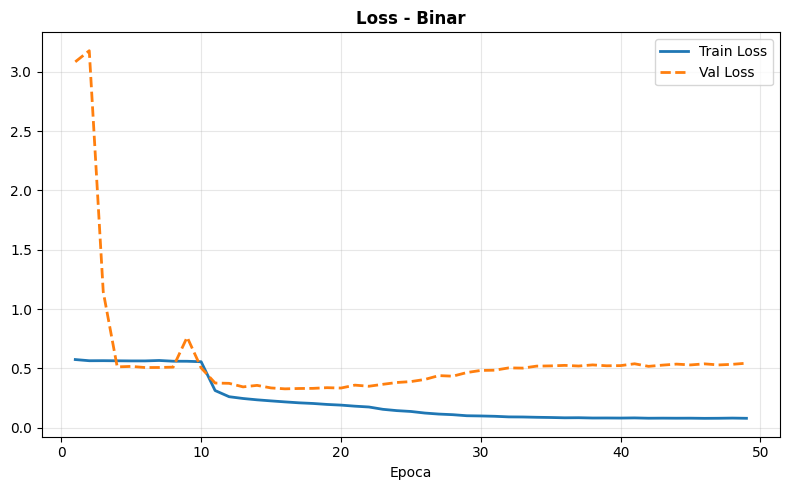

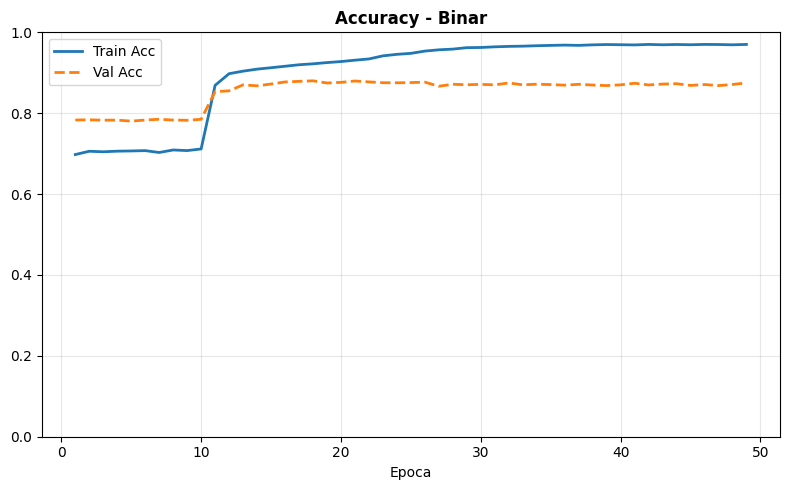

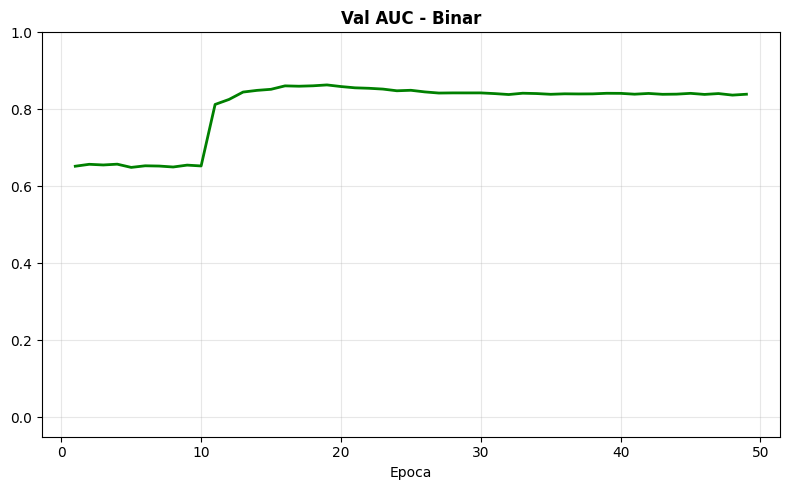

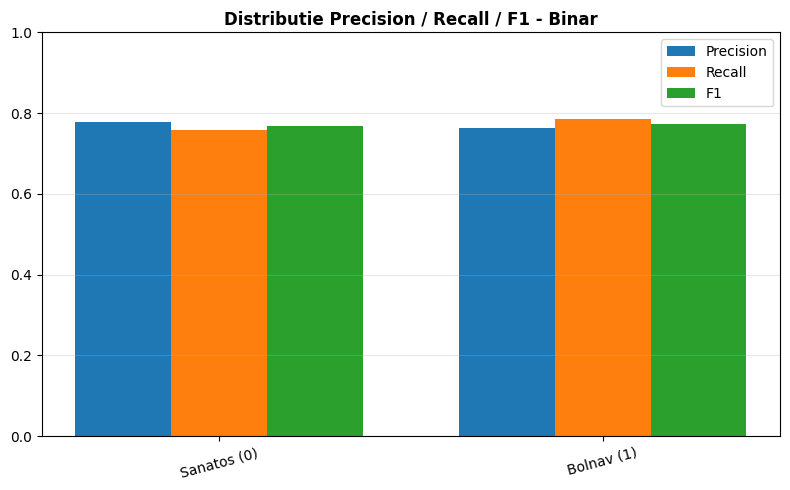

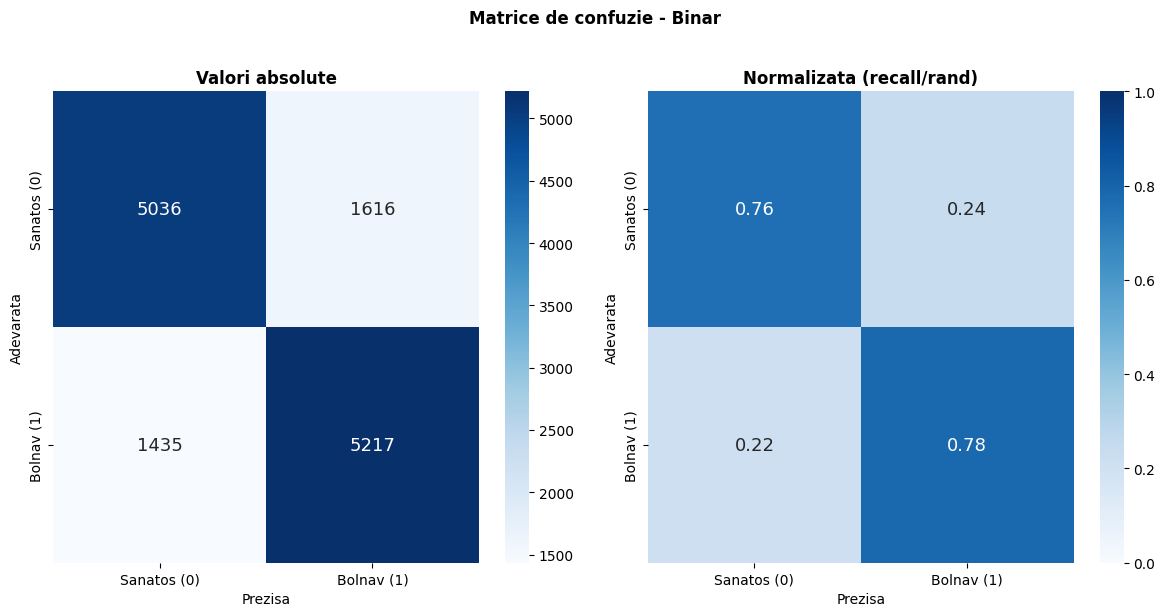

Grafice salvate in Rezultate_main\binar


In [10]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, fbeta_score

model.load_state_dict(torch.load(DIR_BINAR / 'efficientnet_b3_binar_best.pth')); model.eval()
CN_BIN = ['Sanatos (0)', 'Bolnav (1)']

# Prag optim pe validare (F-beta=2: FN sunt mai grave la screening medical)
v_probs, v_targets = [], []
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Val (prag)"):
        images = images.to(device)
        v_probs.extend(torch.sigmoid(model(images).squeeze(1)).cpu().numpy())
        v_targets.extend(labels.numpy())
v_probs = np.array(v_probs)
beta = 2.0
best_thr, best_fb = 0.5, 0.0
for t in np.linspace(0.01, 0.99, 200):
    fb = fbeta_score(v_targets, (v_probs > t).astype(int), beta=beta, pos_label=1, zero_division=0)
    if fb > best_fb:
        best_fb, best_thr = fb, t
print(f"Prag optim pe F{beta}: {best_thr:.3f} (F{beta}={best_fb:.3f})")

# Probabilitati pe TEST
test_probs, test_targets = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testare"):
        images = images.to(device)
        test_probs.extend(torch.sigmoid(model(images).squeeze(1)).cpu().numpy())
        test_targets.extend(labels.numpy())
test_probs = np.array(test_probs)
test_auc = roc_auc_score(test_targets, test_probs)
print(f"\nTest AUC: {test_auc:.4f}")

for label, t in [("prag 0.5", 0.5), (f"prag {best_thr:.3f} (din val)", best_thr)]:
    preds = (test_probs > t).astype(int)
    print(f"\nRAPORT - {label}:")
    print(classification_report(test_targets, preds, target_names=CN_BIN, labels=[0,1], digits=3))

test_pred = (test_probs > best_thr).astype(int)

# Grafice -> Rezultate_main/binar/
plot_curbe(history["train_loss"], history["val_loss"], history["train_acc"], history["val_acc"],
           history["val_auc"], 'AUC', DIR_BINAR, '- Binar')
plot_prf(test_targets, test_pred, CN_BIN, DIR_BINAR, '- Binar')
plot_confuzie(test_targets, test_pred, CN_BIN, DIR_BINAR, '- Binar')
print(f"Grafice salvate in {DIR_BINAR}")


## Evaluare pe test (prag ales pe validare - 3 variante)

Alegem pragul de decizie pe setul de **validare** (Youden's J = max(TPR − FPR)) și îl aplicăm pe test. Raportăm și varianta la pragul standard 0.5 pentru comparație.

Val (prag): 100%|██████████| 416/416 [01:27<00:00,  4.75it/s]


Prag optim pe F2.0: 0.113 (F2.0=0.700)


Testare: 100%|██████████| 416/416 [01:30<00:00,  4.59it/s]



Test AUC: 0.8569

RAPORT - prag 0.5:
              precision    recall  f1-score   support

 Sanatos (0)      0.687     0.965     0.803      6652
  Bolnav (1)      0.941     0.561     0.703      6652

    accuracy                          0.763     13304
   macro avg      0.814     0.763     0.753     13304
weighted avg      0.814     0.763     0.753     13304


RAPORT - prag 0.113 (din val):
              precision    recall  f1-score   support

 Sanatos (0)      0.784     0.738     0.760      6652
  Bolnav (1)      0.752     0.797     0.774      6652

    accuracy                          0.767     13304
   macro avg      0.768     0.767     0.767     13304
weighted avg      0.768     0.767     0.767     13304



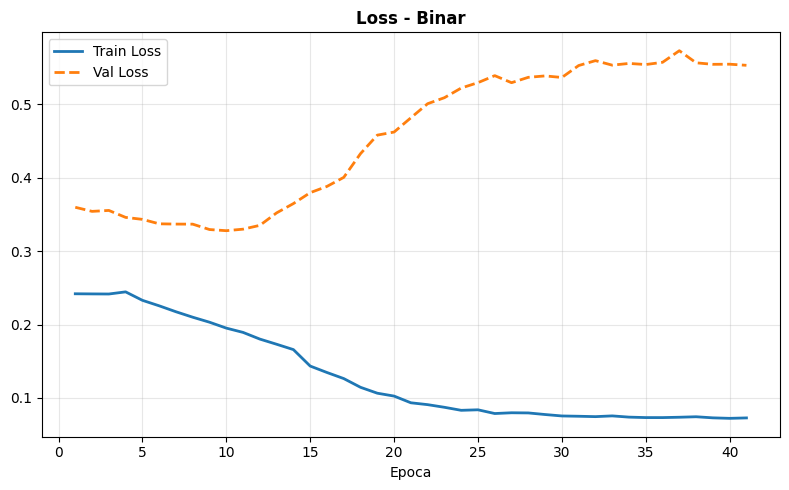

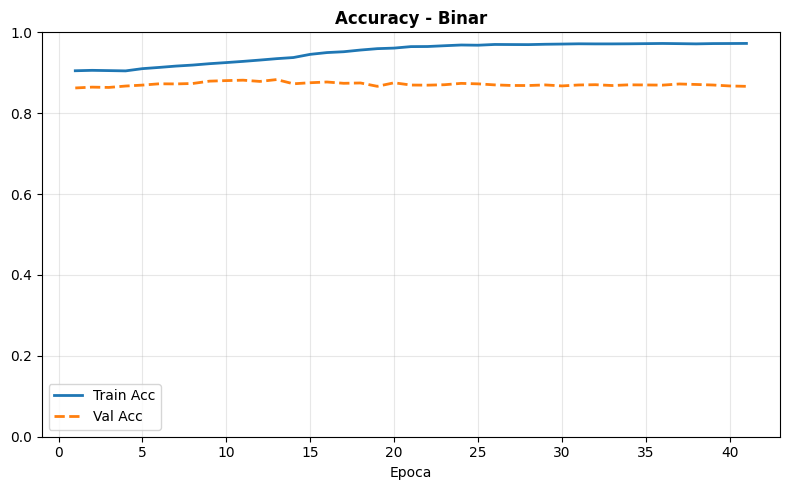

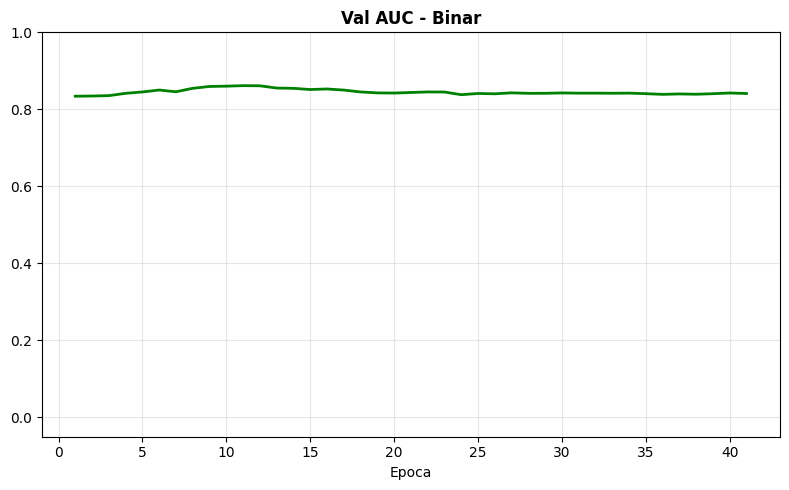

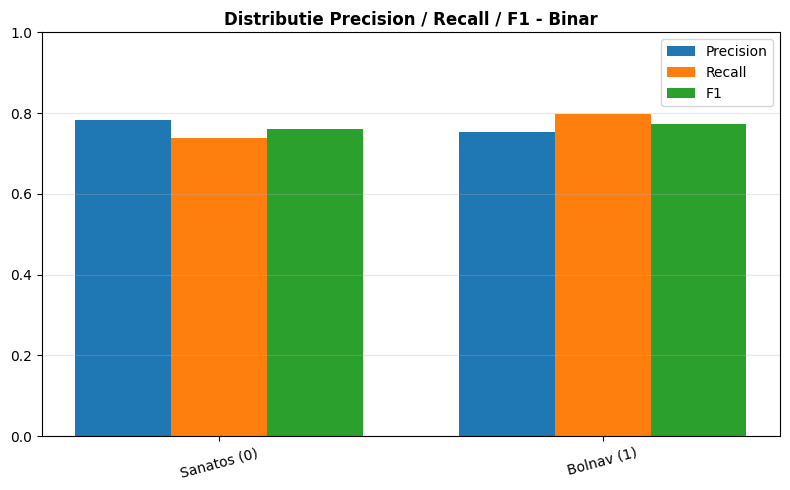

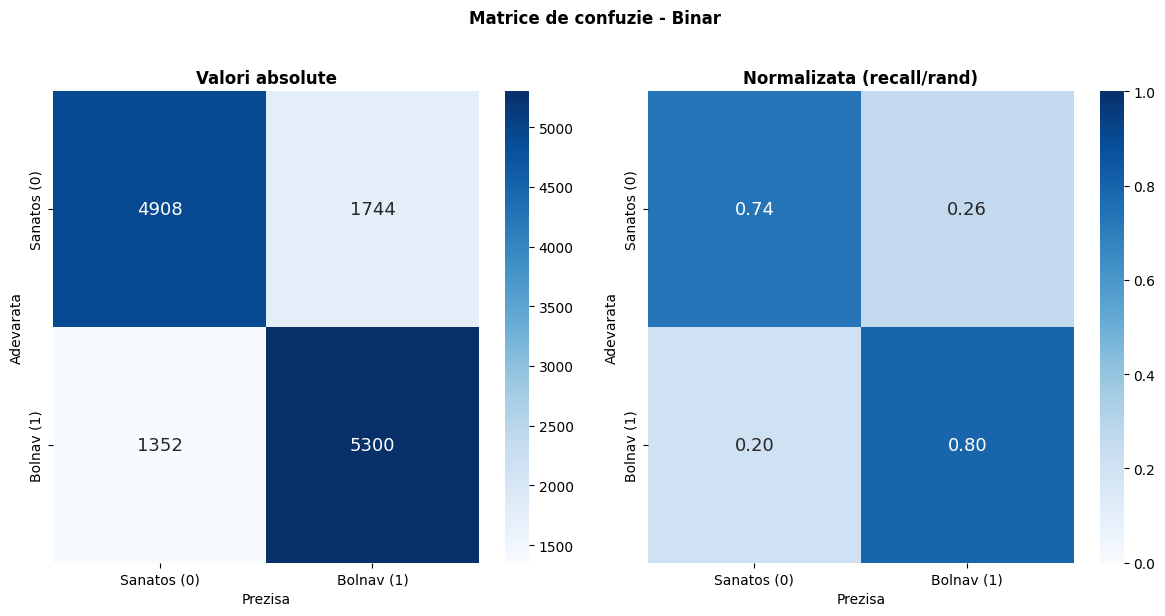

Grafice salvate in Rezultate_main\binar


In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, fbeta_score

model.load_state_dict(torch.load(DIR_BINAR / 'efficientnet_b3_binar_best.pth')); model.eval()
CN_BIN = ['Sanatos (0)', 'Bolnav (1)']

# Prag optim pe validare (F-beta=2: FN sunt mai grave la screening medical)
v_probs, v_targets = [], []
with torch.no_grad():
    for images, labels in tqdm(val_loader, desc="Val (prag)"):
        images = images.to(device)
        v_probs.extend(torch.sigmoid(model(images).squeeze(1)).cpu().numpy())
        v_targets.extend(labels.numpy())
v_probs = np.array(v_probs)
beta = 2.0
best_thr, best_fb = 0.5, 0.0
for t in np.linspace(0.01, 0.99, 200):
    fb = fbeta_score(v_targets, (v_probs > t).astype(int), beta=beta, pos_label=1, zero_division=0)
    if fb > best_fb:
        best_fb, best_thr = fb, t
print(f"Prag optim pe F{beta}: {best_thr:.3f} (F{beta}={best_fb:.3f})")

# Probabilitati pe TEST
test_probs, test_targets = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testare"):
        images = images.to(device)
        test_probs.extend(torch.sigmoid(model(images).squeeze(1)).cpu().numpy())
        test_targets.extend(labels.numpy())
test_probs = np.array(test_probs)
test_auc = roc_auc_score(test_targets, test_probs)
print(f"\nTest AUC: {test_auc:.4f}")

for label, t in [("prag 0.5", 0.5), (f"prag {best_thr:.3f} (din val)", best_thr)]:
    preds = (test_probs > t).astype(int)
    print(f"\nRAPORT - {label}:")
    print(classification_report(test_targets, preds, target_names=CN_BIN, labels=[0,1], digits=3))

test_pred = (test_probs > best_thr).astype(int)

# Grafice -> Rezultate_main/binar/
plot_curbe(history["train_loss"], history["val_loss"], history["train_acc"], history["val_acc"],
           history["val_auc"], 'AUC', DIR_BINAR, '- Binar')
plot_prf(test_targets, test_pred, CN_BIN, DIR_BINAR, '- Binar')
plot_confuzie(test_targets, test_pred, CN_BIN, DIR_BINAR, '- Binar')
print(f"Grafice salvate in {DIR_BINAR}")


Prag optim pe F2.0: 0.074 (F2.0=0.692)


Testare: 100%|██████████| 416/416 [01:09<00:00,  6.02it/s]


Test AUC: 0.8558

RAPORT - prag 0.5:
              precision    recall  f1-score   support

 Sanatos (0)      0.711     0.941     0.810      6652
  Bolnav (1)      0.912     0.618     0.737      6652

    accuracy                          0.779     13304
   macro avg      0.812     0.779     0.773     13304
weighted avg      0.812     0.779     0.773     13304


RAPORT - prag 0.074 (din val):
              precision    recall  f1-score   support

 Sanatos (0)      0.807     0.581     0.676      6652
  Bolnav (1)      0.673     0.861     0.755      6652

    accuracy                          0.721     13304
   macro avg      0.740     0.721     0.716     13304
weighted avg      0.740     0.721     0.716     13304



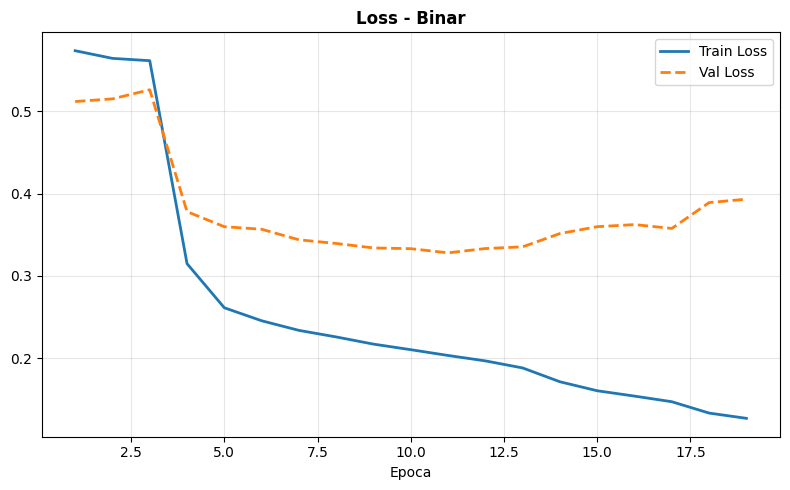

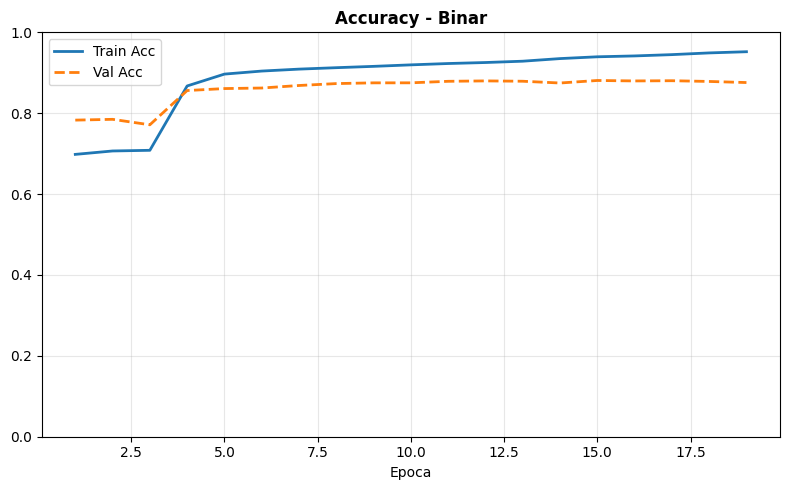

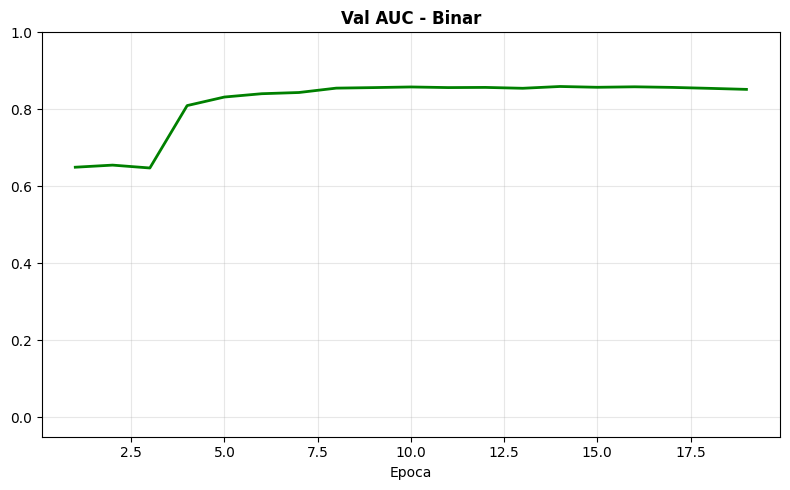

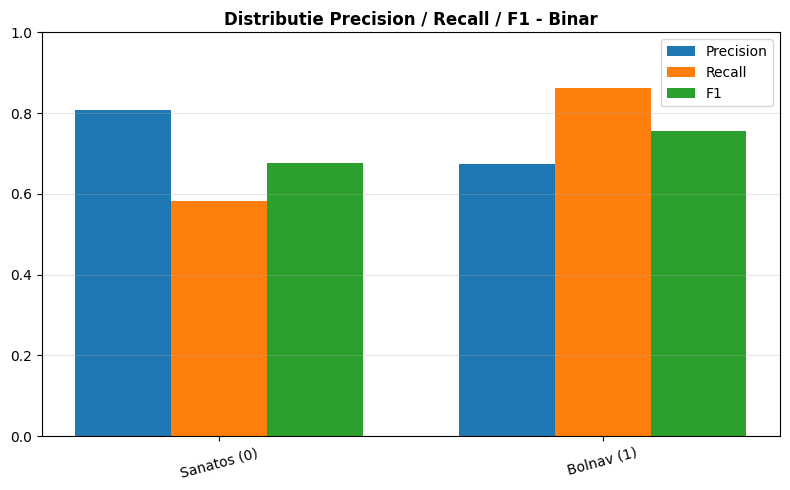

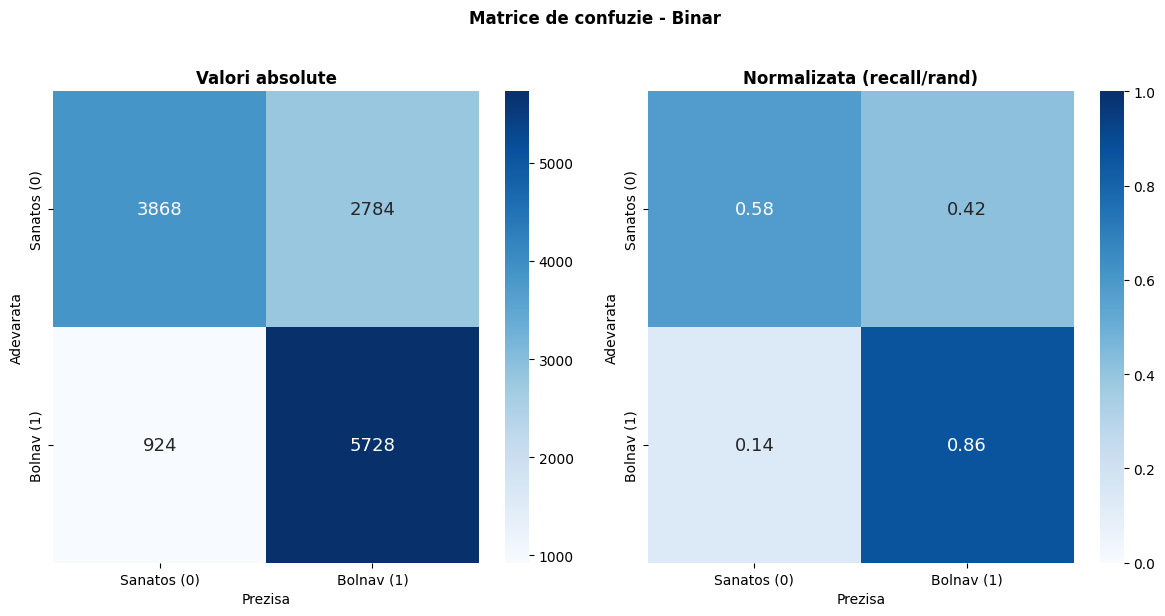

Grafice salvate in Rezultate_main\binar


In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, fbeta_score, f1_score

model.load_state_dict(torch.load(DIR_BINAR / 'efficientnet_b3_binar_best.pth')); model.eval()
CN_BIN = ['Sanatos (0)', 'Bolnav (1)']

# beta=2 → FN sunt de 2x mai grave decât FP (recomandat pentru screening medical)
# beta=1 → F1 clasic, egal
# beta=0.5 → FP sunt mai grave (nu recomandat pentru DR)

beta = 2.0
best_thr, best_fb = 0.5, 0.0

for t in np.linspace(0.01, 0.99, 200):
    preds = (np.array(val_probs) > t).astype(int)
    fb = fbeta_score(val_targets, preds, beta=beta, pos_label=1, zero_division=0)
    if fb > best_fb:
        best_fb = fb
        best_thr = t

print(f"Prag optim pe F{beta}: {best_thr:.3f} (F{beta}={best_fb:.3f})")

# Probabilitati pe TEST
test_probs, test_targets = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testare"):
        images = images.to(device)
        test_probs.extend(torch.sigmoid(model(images).squeeze(1)).cpu().numpy())
        test_targets.extend(labels.numpy())
test_probs = np.array(test_probs)
test_auc = roc_auc_score(test_targets, test_probs)
print(f"\nTest AUC: {test_auc:.4f}")

for label, t in [("prag 0.5", 0.5), (f"prag {best_thr:.3f} (din val)", best_thr)]:
    preds = (test_probs > t).astype(int)
    print(f"\nRAPORT - {label}:")
    print(classification_report(test_targets, preds, target_names=CN_BIN, labels=[0,1], digits=3))

test_pred = (test_probs > best_thr).astype(int)

# Grafice -> Rezultate_main/binar/
plot_curbe(history["train_loss"], history["val_loss"], history["train_acc"], history["val_acc"],
           history["val_auc"], 'AUC', DIR_BINAR, '- Binar')
plot_prf(test_targets, test_pred, CN_BIN, DIR_BINAR, '- Binar')
plot_confuzie(test_targets, test_pred, CN_BIN, DIR_BINAR, '- Binar')
print(f"Grafice salvate in {DIR_BINAR}")


Prag optim pe F1.0: 0.369 (F1.0=0.683)


Testare: 100%|██████████| 416/416 [01:08<00:00,  6.10it/s]


Test AUC: 0.8558

RAPORT - prag 0.5:
              precision    recall  f1-score   support

 Sanatos (0)      0.711     0.941     0.810      6652
  Bolnav (1)      0.912     0.618     0.737      6652

    accuracy                          0.779     13304
   macro avg      0.812     0.779     0.773     13304
weighted avg      0.812     0.779     0.773     13304


RAPORT - prag 0.369 (din val):
              precision    recall  f1-score   support

 Sanatos (0)      0.729     0.914     0.811      6652
  Bolnav (1)      0.884     0.661     0.756      6652

    accuracy                          0.787     13304
   macro avg      0.807     0.787     0.784     13304
weighted avg      0.807     0.787     0.784     13304



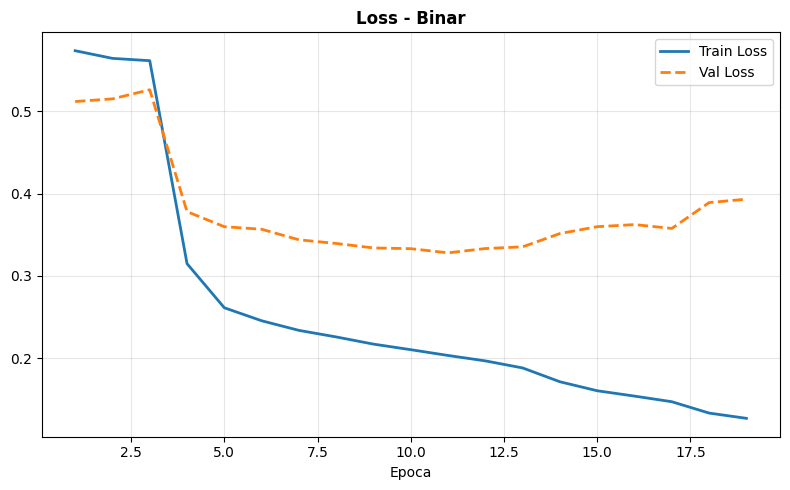

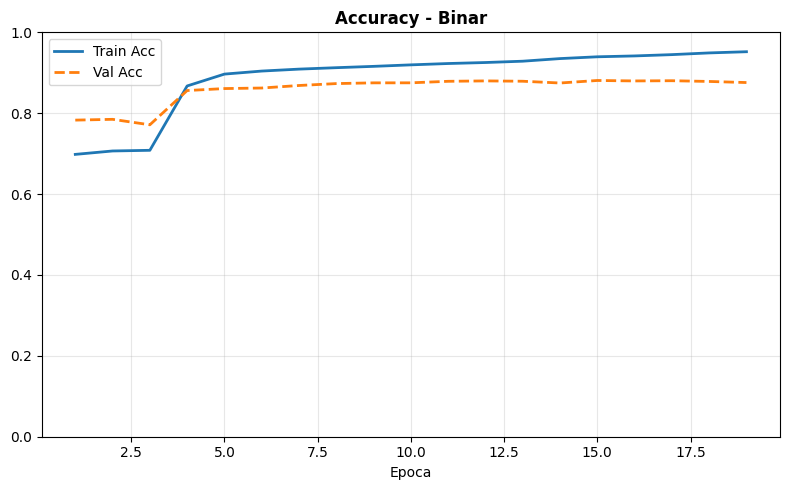

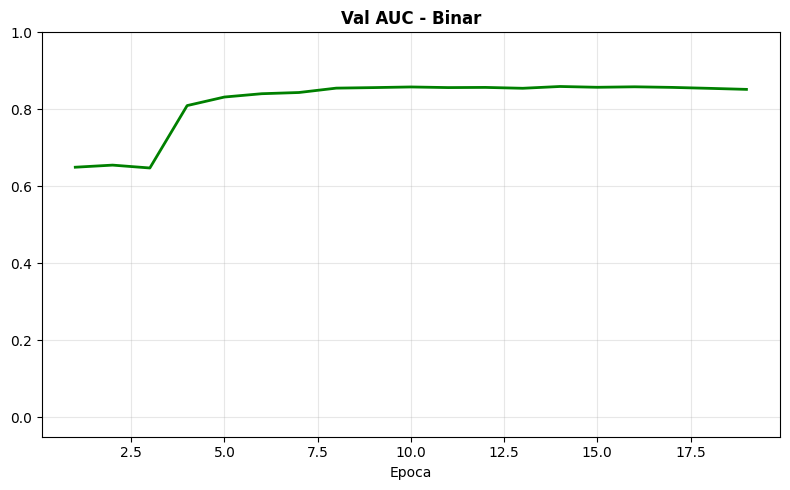

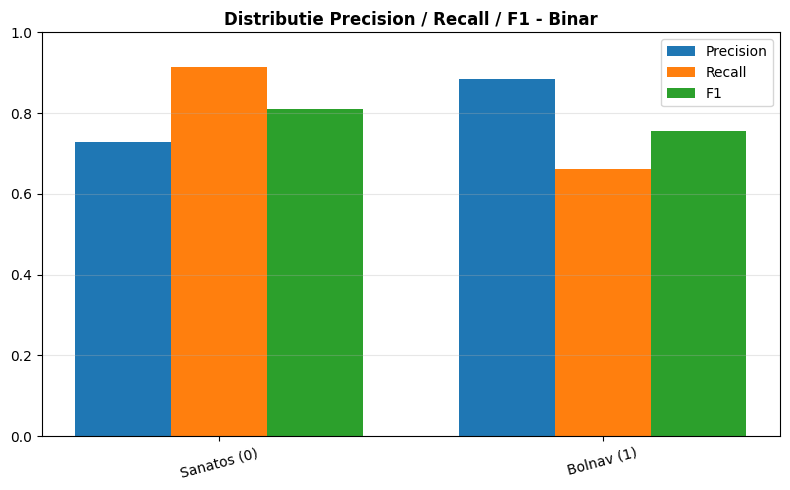

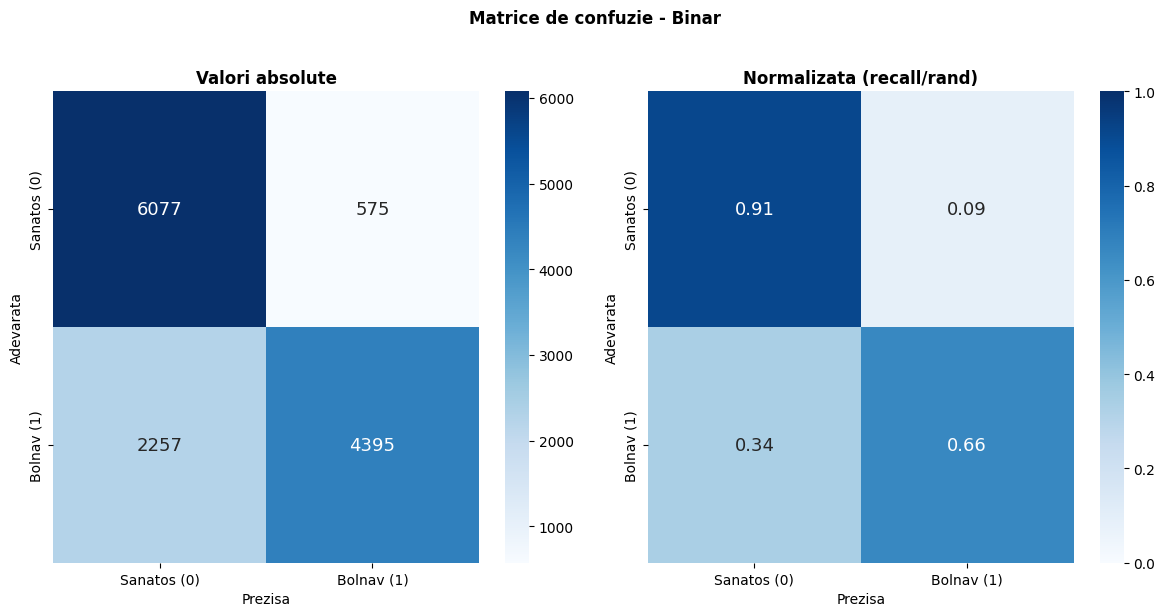

Grafice salvate in Rezultate_main\binar


In [11]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, fbeta_score, f1_score

model.load_state_dict(torch.load(DIR_BINAR / 'efficientnet_b3_binar_best.pth')); model.eval()
CN_BIN = ['Sanatos (0)', 'Bolnav (1)']

# beta=2 → FN sunt de 2x mai grave decât FP (recomandat pentru screening medical)
# beta=1 → F1 clasic, egal
# beta=0.5 → FP sunt mai grave (nu recomandat pentru DR)

beta = 1.0
best_thr, best_fb = 0.5, 0.0

for t in np.linspace(0.01, 0.99, 200):
    preds = (np.array(val_probs) > t).astype(int)
    fb = fbeta_score(val_targets, preds, beta=beta, pos_label=1, zero_division=0)
    if fb > best_fb:
        best_fb = fb
        best_thr = t

print(f"Prag optim pe F{beta}: {best_thr:.3f} (F{beta}={best_fb:.3f})")

# Probabilitati pe TEST
test_probs, test_targets = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testare"):
        images = images.to(device)
        test_probs.extend(torch.sigmoid(model(images).squeeze(1)).cpu().numpy())
        test_targets.extend(labels.numpy())
test_probs = np.array(test_probs)
test_auc = roc_auc_score(test_targets, test_probs)
print(f"\nTest AUC: {test_auc:.4f}")

for label, t in [("prag 0.5", 0.5), (f"prag {best_thr:.3f} (din val)", best_thr)]:
    preds = (test_probs > t).astype(int)
    print(f"\nRAPORT - {label}:")
    print(classification_report(test_targets, preds, target_names=CN_BIN, labels=[0,1], digits=3))

test_pred = (test_probs > best_thr).astype(int)

# Grafice -> Rezultate_main/binar/
plot_curbe(history["train_loss"], history["val_loss"], history["train_acc"], history["val_acc"],
           history["val_auc"], 'AUC', DIR_BINAR, '- Binar')
plot_prf(test_targets, test_pred, CN_BIN, DIR_BINAR, '- Binar')
plot_confuzie(test_targets, test_pred, CN_BIN, DIR_BINAR, '- Binar')
print(f"Grafice salvate in {DIR_BINAR}")


Prag optim pe F0.5: 0.832 (F0.5=0.781)


Testare: 100%|██████████| 416/416 [01:07<00:00,  6.18it/s]


Test AUC: 0.8558

RAPORT - prag 0.5:
              precision    recall  f1-score   support

 Sanatos (0)      0.711     0.941     0.810      6652
  Bolnav (1)      0.912     0.618     0.737      6652

    accuracy                          0.779     13304
   macro avg      0.812     0.779     0.773     13304
weighted avg      0.812     0.779     0.773     13304


RAPORT - prag 0.832 (din val):
              precision    recall  f1-score   support

 Sanatos (0)      0.668     0.984     0.796      6652
  Bolnav (1)      0.969     0.512     0.670      6652

    accuracy                          0.748     13304
   macro avg      0.819     0.748     0.733     13304
weighted avg      0.819     0.748     0.733     13304



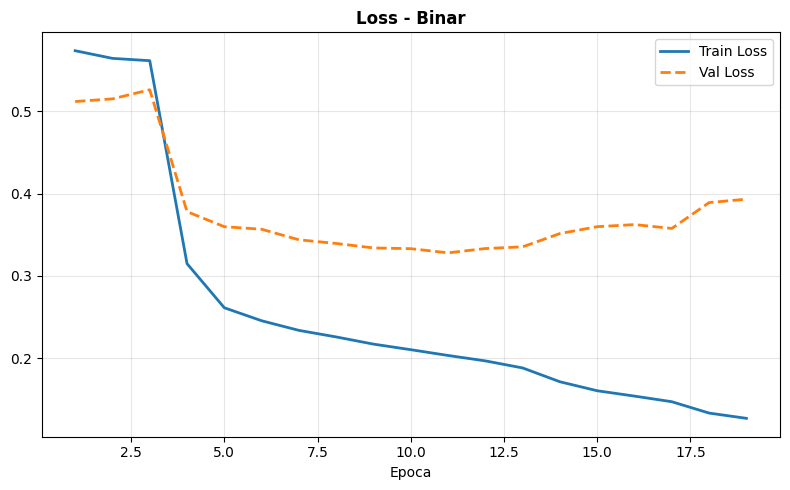

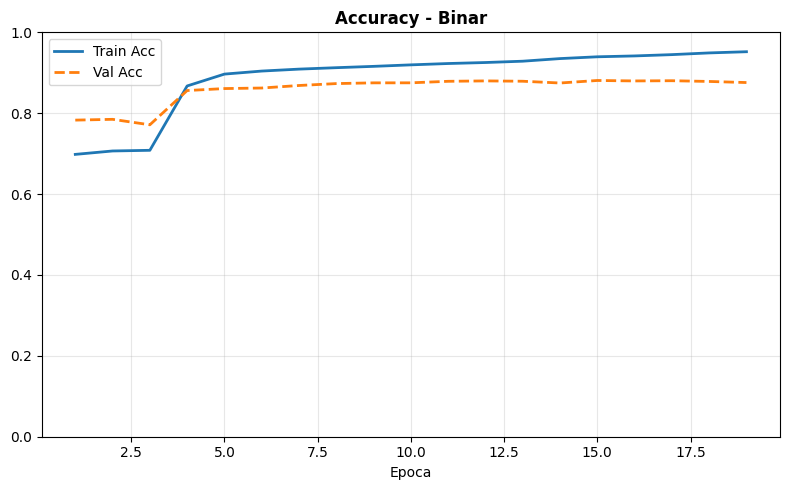

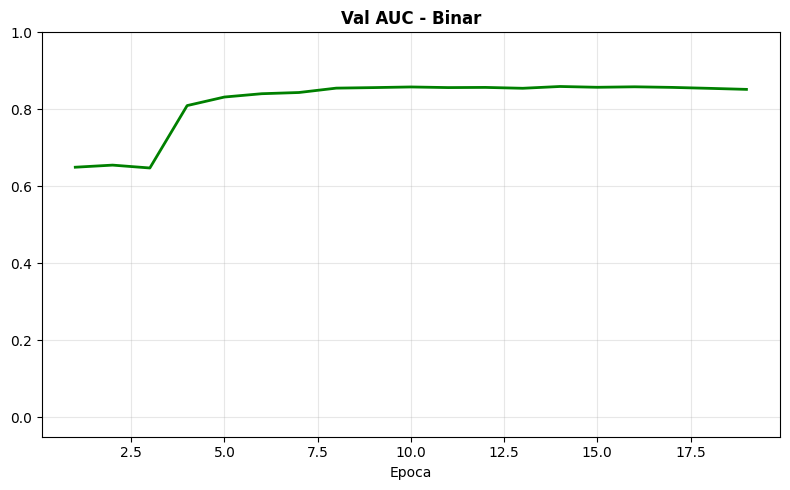

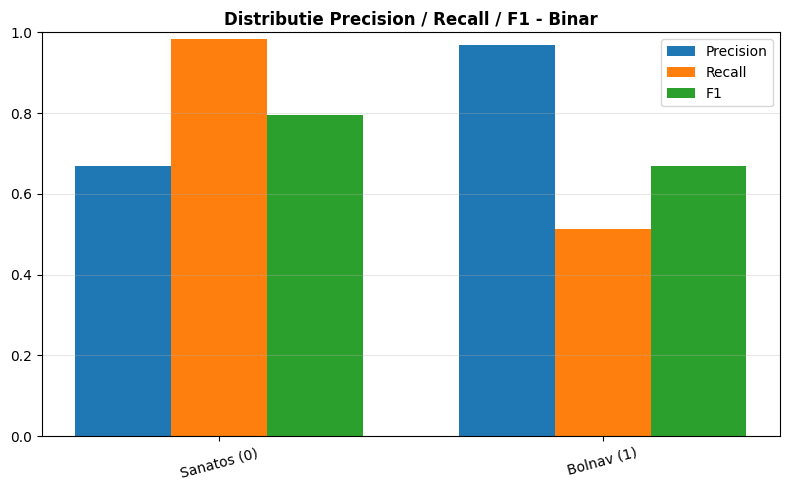

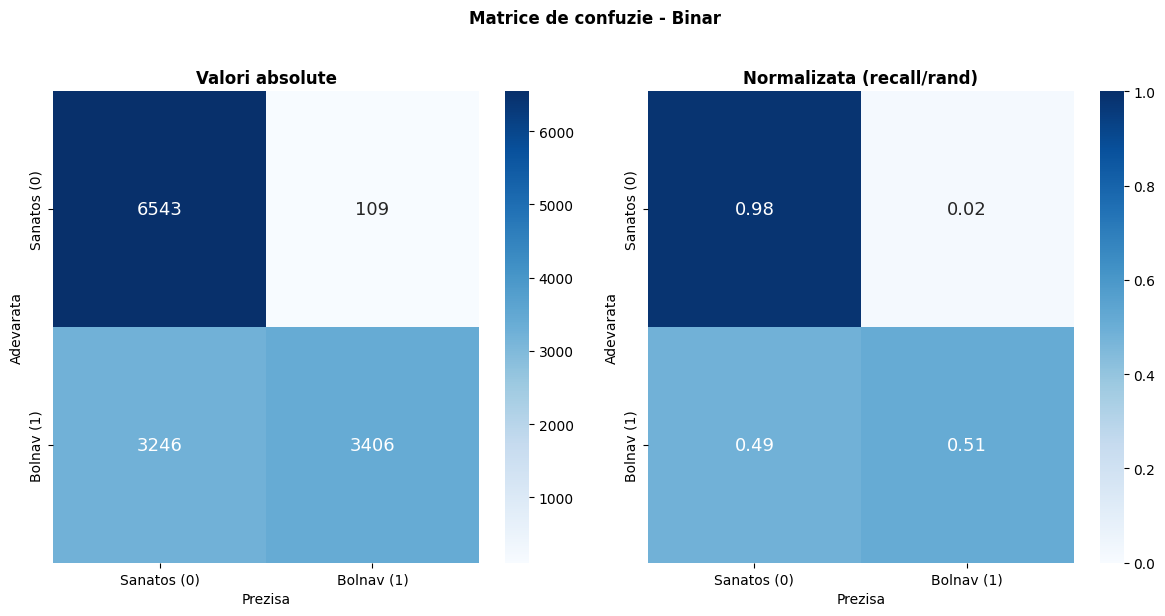

Grafice salvate in Rezultate_main\binar


In [12]:
import seaborn as sns
from sklearn.metrics import confusion_matrix, fbeta_score, f1_score

model.load_state_dict(torch.load(DIR_BINAR / 'efficientnet_b3_binar_best.pth')); model.eval()
CN_BIN = ['Sanatos (0)', 'Bolnav (1)']

# beta=2 → FN sunt de 2x mai grave decât FP (recomandat pentru screening medical)
# beta=1 → F1 clasic, egal
# beta=0.5 → FP sunt mai grave (nu recomandat pentru DR)

beta = 0.5
best_thr, best_fb = 0.5, 0.0

for t in np.linspace(0.01, 0.99, 200):
    preds = (np.array(val_probs) > t).astype(int)
    fb = fbeta_score(val_targets, preds, beta=beta, pos_label=1, zero_division=0)
    if fb > best_fb:
        best_fb = fb
        best_thr = t

print(f"Prag optim pe F{beta}: {best_thr:.3f} (F{beta}={best_fb:.3f})")

# Probabilitati pe TEST
test_probs, test_targets = [], []
with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Testare"):
        images = images.to(device)
        test_probs.extend(torch.sigmoid(model(images).squeeze(1)).cpu().numpy())
        test_targets.extend(labels.numpy())
test_probs = np.array(test_probs)
test_auc = roc_auc_score(test_targets, test_probs)
print(f"\nTest AUC: {test_auc:.4f}")

for label, t in [("prag 0.5", 0.5), (f"prag {best_thr:.3f} (din val)", best_thr)]:
    preds = (test_probs > t).astype(int)
    print(f"\nRAPORT - {label}:")
    print(classification_report(test_targets, preds, target_names=CN_BIN, labels=[0,1], digits=3))

test_pred = (test_probs > best_thr).astype(int)

# Grafice -> Rezultate_main/binar/
plot_curbe(history["train_loss"], history["val_loss"], history["train_acc"], history["val_acc"],
           history["val_auc"], 'AUC', DIR_BINAR, '- Binar')
plot_prf(test_targets, test_pred, CN_BIN, DIR_BINAR, '- Binar')
plot_confuzie(test_targets, test_pred, CN_BIN, DIR_BINAR, '- Binar')
print(f"Grafice salvate in {DIR_BINAR}")


# Clasificare 1-4 — secțiune comună + 3 ramuri (fără duplicate)

Setup-ul (date + funcții) e definit o singură dată. Cele 3 ramuri de mai jos rulează funcția `ruleaza_ramura(mode)` cu codul tău de antrenare/evaluare — `crossentropy`, `regression`, `ordinal`. Fiecare salvează modelul și graficele în `Rezultate_main/clasificare_<mode>/`.

In [9]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import models, transforms
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, cohen_kappa_score
import scipy.optimize as opt
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

# ================================================================
# CONFIGURARE
# ================================================================
DATA_DIR    = r'B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\eyepacs\eyepacs_1_4'
IMG_SIZE    = 300
BATCH_SIZE  = 32   # la 512: scade la 16 daca iei CUDA Out of Memory
NUM_CLASSES = 4
CLASS_NAMES = ['Stadiul 1', 'Stadiul 2', 'Stadiul 3', 'Stadiul 4']
NUM_WORKERS = 8   # pe Windows: daca ingheata la granita dintre epoci, pune 0

_norm = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    _norm,
])
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    _norm,
])

LOCAL_DIR = Path(r'B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\Notebooks\Main\Local')
if str(LOCAL_DIR) not in sys.path:
    sys.path.insert(0, str(LOCAL_DIR))
from dataset_1_4 import MultiClassRetinopathyDataset

train_ds = MultiClassRetinopathyDataset(os.path.join(DATA_DIR, 'train'), transform=train_transform)
val_ds   = MultiClassRetinopathyDataset(os.path.join(DATA_DIR, 'val'),   transform=test_transform)
test_ds  = MultiClassRetinopathyDataset(os.path.join(DATA_DIR, 'test'),  transform=test_transform)

loader_kwargs = {'num_workers': NUM_WORKERS, 'pin_memory': torch.cuda.is_available()}
if NUM_WORKERS > 0:
    loader_kwargs['prefetch_factor'] = 1

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  **loader_kwargs)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, **loader_kwargs)

print("=== STATISTICI DATASET ===")
print(f"Mapare clase: {train_ds.class_to_idx}")
for split_name, ds in [("TRAIN", train_ds), ("VAL", val_ds), ("TEST", test_ds)]:
    targets = np.array(ds.targets)
    print(f"{split_name} ({len(ds)}): " + ", ".join(f"{c}={(targets==i).sum()}" for i,c in enumerate(CLASS_NAMES)))
print(f"Batch-uri train: {len(train_loader)}")


=== STATISTICI DATASET ===
Mapare clase: {'stadiul_1': 0, 'stadiul_2': 1, 'stadiul_3': 2, 'stadiul_4': 3}
TRAIN (40000): Stadiul 1=10000, Stadiul 2=10000, Stadiul 3=10000, Stadiul 4=10000
VAL (3503): Stadiul 1=930, Stadiul 2=1973, Stadiul 3=313, Stadiul 4=287
TEST (3504): Stadiul 1=931, Stadiul 2=1973, Stadiul 3=313, Stadiul 4=287
Batch-uri train: 1250


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Antrenam pe: {device}")

HEAD_LR_PHASE1          = 1e-3
BACKBONE_LR_PHASE2      = 1e-4
HEAD_LR_PHASE2          = 3e-4
WEIGHT_DECAY            = 1e-4
DROPOUT                 = 0.40
FREEZE_BACKBONE_EPOCHS  = 5
TOTAL_EPOCHS            = 50
EARLY_STOPPING_PATIENCE = 30
LABEL_SMOOTHING         = 0.10   # folosit doar la crossentropy
SEED                    = 42

torch.manual_seed(SEED); np.random.seed(SEED)

# ---------------- CORAL (mod ordinal) ----------------
class CoralLayer(nn.Module):
    """Un singur set de ponderi + K-1 bias-uri independente => praguri monotone."""
    def __init__(self, in_features, num_classes):
        super().__init__()
        self.fc = nn.Linear(in_features, 1, bias=False)
        self.bias = nn.Parameter(torch.zeros(num_classes - 1).float())
    def forward(self, x):
        return self.fc(x) + self.bias            # [B, K-1]

def labels_to_levels(labels, num_classes):
    rng = torch.arange(num_classes - 1, device=labels.device).unsqueeze(0)
    return (labels.unsqueeze(1) > rng).float()    # ex: label 2 -> [1,1,0]

def coral_loss(logits, levels):
    return (-torch.sum(F.logsigmoid(logits) * levels
            + (F.logsigmoid(logits) - logits) * (1 - levels), dim=1)).mean()

def coral_decode(logits):
    return (torch.sigmoid(logits) > 0.5).sum(dim=1)   # numara cate praguri sunt depasite

# ---------------- Construire model in functie de MODE ----------------
def build_model(mode):
    m = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
    nf = m.classifier[1].in_features
    if mode == "crossentropy":
        m.classifier[1] = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(nf, NUM_CLASSES))
    elif mode == "regression":
        m.classifier[1] = nn.Sequential(nn.Dropout(DROPOUT), nn.Linear(nf, 1))
    elif mode == "ordinal":
        m.classifier = nn.Sequential(nn.Dropout(DROPOUT), CoralLayer(nf, NUM_CLASSES))
    else:
        raise ValueError(f"MODE necunoscut: {mode}")
    return m.to(device)

ce_criterion  = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
reg_criterion = nn.SmoothL1Loss()

def compute_loss(out, labels):
    if MODE == "crossentropy":
        return ce_criterion(out, labels)
    if MODE == "regression":
        return reg_criterion(out.squeeze(1), labels.float())
    if MODE == "ordinal":
        return coral_loss(out, labels_to_levels(labels, NUM_CLASSES))

def decode(out):
    """Predictii intregi 0..K-1 pentru monitorizare (regresie: rotunjire naiva)."""
    if MODE == "crossentropy":
        return out.argmax(1)
    if MODE == "regression":
        return out.squeeze(1).round().clamp(0, NUM_CLASSES - 1).long()
    if MODE == "ordinal":
        return coral_decode(out)

def raw_scores(out):
    """Iesirea continua pentru regresie (necesara la rounder-ul optimizat)."""
    return out.squeeze(1) if MODE == "regression" else None

# ---------------- Rounder optimizat pe validare (doar regresie) ----------------
class OptimizedRounder:
    """Alege K-1 praguri care maximizeaza QWK pe validare (Nelder-Mead)."""
    def __init__(self, n_classes): self.n_classes = n_classes; self.coef_ = None
    def _classify(self, X, coef):
        return np.clip(np.digitize(X, np.sort(coef)), 0, self.n_classes - 1)
    def _neg_qwk(self, coef, X, y):
        return -cohen_kappa_score(y, self._classify(X, coef), weights='quadratic')
    def fit(self, X, y):
        init = np.arange(self.n_classes - 1) + 0.5
        r = opt.minimize(self._neg_qwk, init, args=(X, y), method='Nelder-Mead')
        self.coef_ = np.sort(r.x)
    def predict(self, X):
        return self._classify(X, self.coef_)

# ---------------- Freeze/unfreeze + optimizatoare pe faze ----------------
def set_backbone_trainable(m, trainable):
    for name, p in m.named_parameters():
        if not name.startswith("classifier"):
            p.requires_grad = trainable

def split_params(m):
    head     = [p for n, p in m.named_parameters() if n.startswith("classifier")]
    backbone = [p for n, p in m.named_parameters() if not n.startswith("classifier")]
    return head, backbone

def build_optimizer_phase1(m):
    set_backbone_trainable(m, False)
    head, _ = split_params(m)
    o = optim.AdamW(head, lr=HEAD_LR_PHASE1, weight_decay=WEIGHT_DECAY)
    s = optim.lr_scheduler.ReduceLROnPlateau(o, mode='max', factor=0.5, patience=2)
    return o, s

def build_optimizer_phase2(m):
    set_backbone_trainable(m, True)
    head, backbone = split_params(m)
    o = optim.AdamW([{"params": backbone, "lr": BACKBONE_LR_PHASE2},
                     {"params": head,     "lr": HEAD_LR_PHASE2}], weight_decay=WEIGHT_DECAY)
    s = optim.lr_scheduler.ReduceLROnPlateau(o, mode='max', factor=0.5, patience=2)
    return o, s

print("Helperi de clasificare gata (build_model, compute_loss, decode, ...).")


Antrenam pe: cuda
Helperi de clasificare gata (build_model, compute_loss, decode, ...).


In [15]:
def ruleaza_ramura(mode):
    """Codul tau de antrenare in 2 faze + evaluare, pentru un mod. Salveaza in Rezultate_main/clasificare_<mode>/."""
    global MODE
    MODE = mode
    torch.manual_seed(SEED); np.random.seed(SEED)
    out_dir = dir_clasificare(mode)
    CKPT = str(out_dir / 'model_best.pth')

    model = build_model(mode)
    scaler = torch.amp.GradScaler('cuda', enabled=(device.type == 'cuda'))
    optimizer, scheduler = build_optimizer_phase1(model)
    best_val_qwk = -1.0
    epochs_no_improve = 0
    history = {'t_loss': [], 'v_loss': [], 't_acc': [], 'v_acc': [], 'v_qwk': []}

    print(f"=== ANTRENARE [{mode}] - FAZA 1 (backbone inghetat) ===")
    for epoch in range(TOTAL_EPOCHS):
        if epoch == FREEZE_BACKBONE_EPOCHS:
            optimizer, scheduler = build_optimizer_phase2(model)
            print("=== FAZA 2: backbone dezghetat, fine-tuning complet ===")

        # ---- TRAIN ----
        model.train(); train_loss = 0.0; train_preds, train_targets = [], []
        for images, labels in tqdm(train_loader, desc=f"[{mode}] Epoca {epoch+1}/{TOTAL_EPOCHS} [TRAIN]"):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                out = model(images); loss = compute_loss(out, labels)
            scaler.scale(loss).backward(); scaler.step(optimizer); scaler.update()
            train_loss += loss.item() * images.size(0)
            train_preds.extend(decode(out).detach().cpu().tolist())
            train_targets.extend(labels.detach().cpu().tolist())

        # ---- VAL ----
        model.eval(); val_loss = 0.0; val_preds, val_targets = [], []
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"[{mode}] Epoca {epoch+1}/{TOTAL_EPOCHS} [VAL]"):
                images = images.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                    out = model(images); loss = compute_loss(out, labels)
                val_loss += loss.item() * images.size(0)
                val_preds.extend(decode(out).detach().cpu().tolist())
                val_targets.extend(labels.detach().cpu().tolist())

        avg_train_loss = train_loss / len(train_ds)
        avg_val_loss   = val_loss / len(val_ds)
        train_acc = accuracy_score(train_targets, train_preds)
        val_acc = accuracy_score(val_targets, val_preds)
        val_qwk = cohen_kappa_score(val_targets, val_preds, weights='quadratic')
        for k, v in zip(history, [avg_train_loss, avg_val_loss, train_acc, val_acc, val_qwk]):
            history[k].append(v)
        scheduler.step(val_qwk)
        print(f"Epoca {epoch+1}: T_Loss={avg_train_loss:.4f} | V_Loss={avg_val_loss:.4f} "
              f"| T_Acc={train_acc:.4f} | V_Acc={val_acc:.4f} | V_QWK={val_qwk:.4f}")

        if val_qwk > best_val_qwk + 1e-4:
            best_val_qwk = val_qwk; epochs_no_improve = 0
            torch.save(model.state_dict(), CKPT)
            print(f"Model nou salvat! (Val QWK: {best_val_qwk:.4f})")
        else:
            epochs_no_improve += 1
            print(f"Fara imbunatatire pe QWK: {epochs_no_improve}/{EARLY_STOPPING_PATIENCE}")
            if epochs_no_improve >= EARLY_STOPPING_PATIENCE:
                print("Early stopping."); break
    print(f"Cel mai bun Val QWK [{mode}]: {best_val_qwk:.4f}")

    # ---- EVALUARE PE TEST ----
    model.load_state_dict(torch.load(CKPT)); model.eval()
    def collect(loader):
        preds, targets, scores = [], [], []
        with torch.no_grad():
            for images, labels in tqdm(loader, desc=f"[{mode}] eval"):
                images = images.to(device)
                out = model(images)
                preds.extend(decode(out).cpu().tolist())
                targets.extend(labels.tolist())
                if mode == "regression":
                    scores.extend(raw_scores(out).cpu().numpy())
        return np.array(preds), np.array(targets), np.array(scores)

    if mode == "regression":
        _, val_t, val_s = collect(val_loader)
        rounder = OptimizedRounder(NUM_CLASSES); rounder.fit(val_s, val_t)
        np.save(out_dir / 'rounder_coef.npy', rounder.coef_)
        print(f"Praguri optime (din val): {np.round(rounder.coef_, 3)}")
        _, test_t, test_s = collect(test_loader)
        test_p = rounder.predict(test_s)
    else:
        test_p, test_t, _ = collect(test_loader)

    test_acc = accuracy_score(test_t, test_p)
    test_qwk = cohen_kappa_score(test_t, test_p, weights='quadratic')
    print(f"\nTest Accuracy : {test_acc:.4f}\nTest QWK      : {test_qwk:.4f}\n")
    print(classification_report(test_t, test_p, target_names=CLASS_NAMES, labels=list(range(NUM_CLASSES)), digits=3))

    # Grafice -> folderul ramurii
    plot_curbe(history['t_loss'], history['v_loss'], history['t_acc'], history['v_acc'],
               history['v_qwk'], 'QWK', out_dir, f'- [{mode}]')
    plot_prf(test_t, test_p, CLASS_NAMES, out_dir, f'- [{mode}]')
    plot_confuzie(test_t, test_p, CLASS_NAMES, out_dir, f'- [{mode}] QWK={test_qwk:.3f}')
    print(f"Salvat in {out_dir}")
    return {'mode': mode, 'qwk': test_qwk, 'acc': test_acc}

print("Functia ruleaza_ramura gata.")


Functia ruleaza_ramura gata.


### Ramura 2 — regression

=== ANTRENARE [regression] - FAZA 1 (backbone inghetat) ===


[regression] Epoca 1/50 [VAL]: 100%|██████████| 110/110 [00:44<00:00,  2.49it/s]


Epoca 1: T_Loss=0.4123 | V_Loss=0.2929 | T_Acc=0.3697 | V_Acc=0.4742 | V_QWK=0.3913
Model nou salvat! (Val QWK: 0.3913)


[regression] Epoca 2/50 [VAL]: 100%|██████████| 110/110 [00:37<00:00,  2.92it/s]


Epoca 2: T_Loss=0.3931 | V_Loss=0.2698 | T_Acc=0.3847 | V_Acc=0.4956 | V_QWK=0.4154
Model nou salvat! (Val QWK: 0.4154)


...

Epoca 46: T_Loss=0.0285 | V_Loss=0.1690 | T_Acc=0.9342 | V_Acc=0.6526 | V_QWK=0.6314
Fara imbunatatire pe QWK: 30/30
Early stopping.
Cel mai bun Val QWK [regression]: 0.6575


[regression] eval: 100%|██████████| 110/110 [00:42<00:00,  2.62it/s]


Praguri optime (din val): [0.58  1.393 2.158]


[regression] eval: 100%|██████████| 110/110 [00:42<00:00,  2.56it/s]



Test Accuracy : 0.6170
Test QWK      : 0.6576

              precision    recall  f1-score   support

   Stadiul 1      0.559     0.764     0.645       931
   Stadiul 2      0.758     0.576     0.654      1973
   Stadiul 3      0.327     0.530     0.404       313
   Stadiul 4      0.665     0.519     0.583       287

    accuracy                          0.617      3504
   macro avg      0.577     0.597     0.572      3504
weighted avg      0.659     0.617     0.624      3504



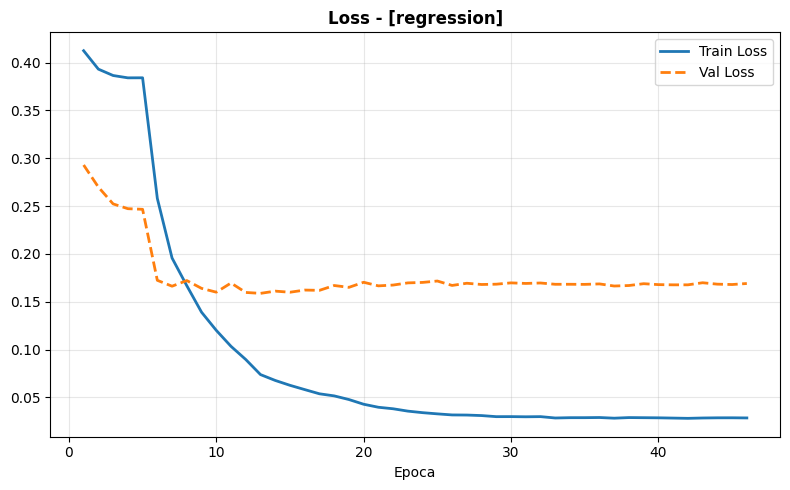

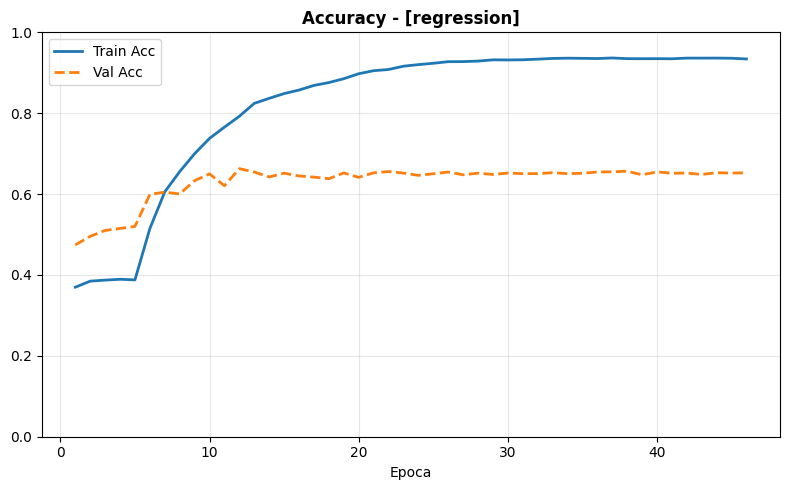

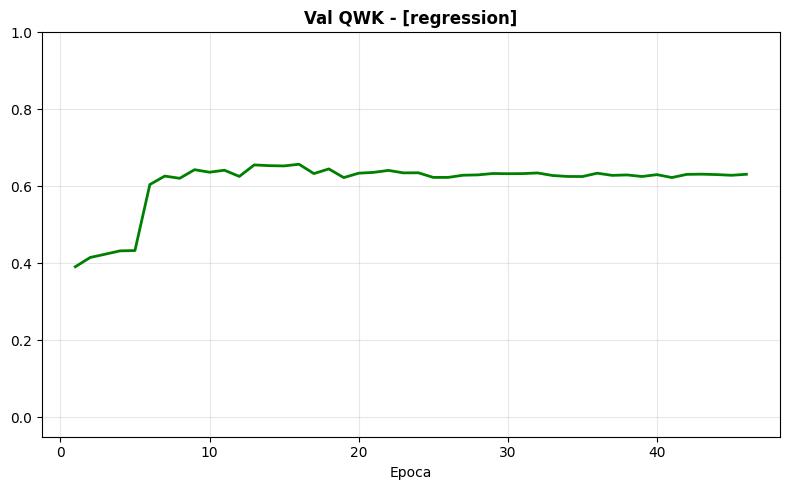

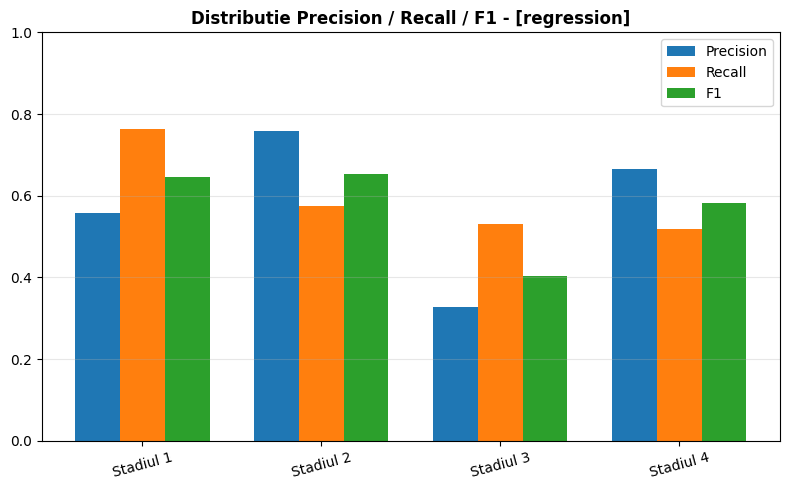

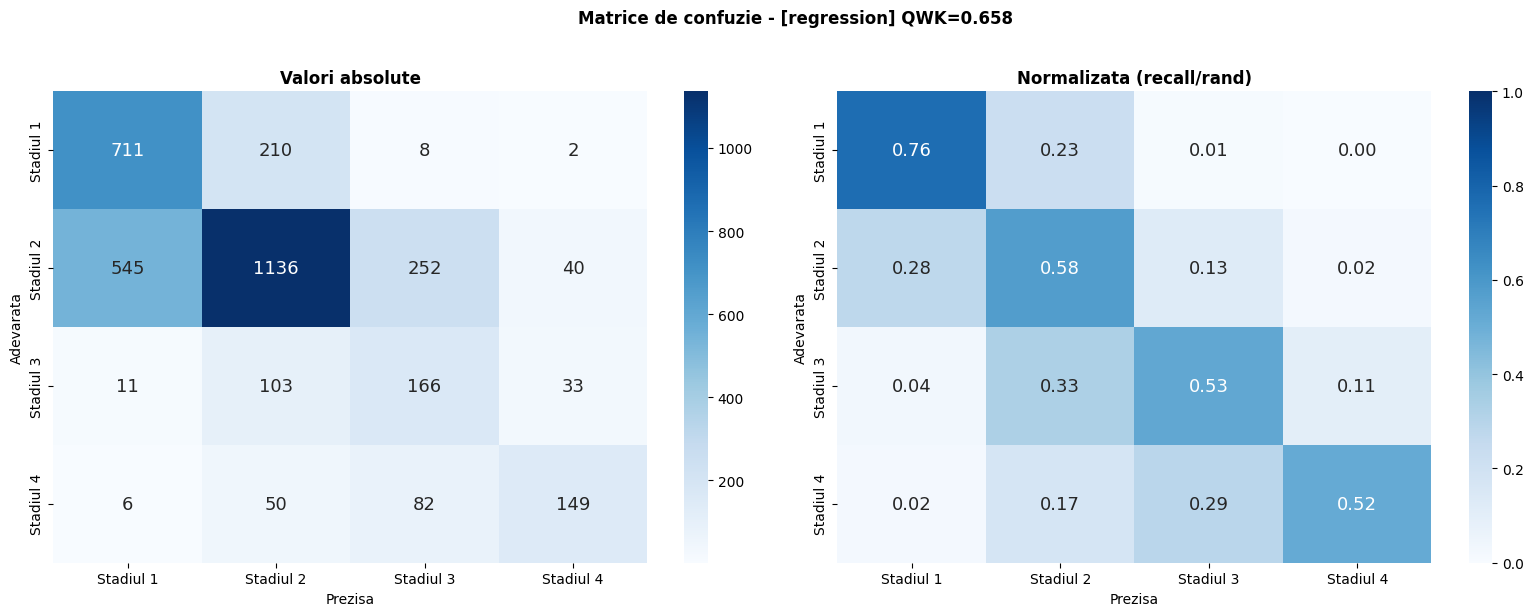

Salvat in Rezultate_main\clasificare_regression


In [16]:
res_reg = ruleaza_ramura("regression")

## Inferență — cascadă (binar → clasificare)

Binarul decide întâi: dacă `p_sick < prag` → **Grad 0 (No DR)**; altfel imaginea merge la clasificator (grad 1-4). Implicit folosim ramura `ordinal`.

In [42]:
from PIL import Image

INFER_MODE = "regression"     # "ordinal" | "crossentropy" | "regression"
PRAG_BINAR = 0.50          # p_sick < PRAG => sanatos (grad 0)

# Reconstruim modelul binar (aceeasi arhitectura ca la antrenare) si il incarcam
def _build_binary():
    m = models.efficientnet_b3(weights=None)
    nf = m.classifier[1].in_features
    m.classifier[1] = nn.Sequential(nn.Dropout(0.40), nn.Linear(nf, 1))
    return m.to(device)

binm = _build_binary()
binm.load_state_dict(torch.load(DIR_BINAR / 'efficientnet_b3_binar_best.pth')); binm.eval()

MODE = INFER_MODE
clsm = build_model(INFER_MODE)
clsm.load_state_dict(torch.load(dir_clasificare(INFER_MODE) / 'model_best.pth')); clsm.eval()

_rounder_coef = None
if INFER_MODE == "regression":
    p = dir_clasificare("regression") / 'rounder_coef.npy'
    if p.exists():
        _rounder_coef = np.load(p)

GRADE_NAMES = ['Grad 0 (No DR)', 'Grad 1', 'Grad 2', 'Grad 3', 'Grad 4']

@torch.no_grad()
def prezice_imagine(path, prag=PRAG_BINAR):
    img = Image.open(path).convert("RGB")
    x = test_transform(img).unsqueeze(0).to(device)
    p_sick = torch.sigmoid(binm(x).squeeze(1)).item()
    if p_sick < prag:
        return {"grad_final": 0, "eticheta": GRADE_NAMES[0], "p_sick": round(p_sick, 3), "etapa": "binar"}
    out = clsm(x)
    if INFER_MODE == "regression":
        s = out.squeeze(1).item()
        if _rounder_coef is not None:
            g = int(np.clip(np.digitize([s], np.sort(_rounder_coef))[0], 0, NUM_CLASSES - 1))
        else:
            g = int(np.clip(round(s), 0, NUM_CLASSES - 1))
    else:
        g = int(decode(out).item())
    grad_final = g + 1   # clasificatorul da 0..3 -> gradele 1..4
    return {"grad_final": grad_final, "eticheta": GRADE_NAMES[grad_final], "p_sick": round(p_sick, 3), "etapa": "cascada"}

# Demo pe cateva imagini din test-ul binar
import random
demo_dir = os.path.join(DATA_DIR, 'test')   # DATA_DIR ramane setat la ultimul dataset incarcat
# folosim explicit folderul binar pentru demo:
demo_dir_bin = r'B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\eyepacs\eyepacs_binar\test'
fisiere = []
if os.path.isdir(demo_dir_bin):
    for cls in os.listdir(demo_dir_bin):
        sub = os.path.join(demo_dir_bin, cls)
        if os.path.isdir(sub):
            for f in os.listdir(sub)[:3]:
                fisiere.append(os.path.join(sub, f))
    for f in random.sample(fisiere, min(6, len(fisiere))):
        print(os.path.basename(f), "->", prezice_imagine(f))
else:
    print("Seteaza demo_dir_bin catre un folder de test ca sa vezi predictii.")


10003_right.png -> {'grad_final': 0, 'eticheta': 'Grad 0 (No DR)', 'p_sick': 0.087, 'etapa': 'binar'}
10016_left.png -> {'grad_final': 1, 'eticheta': 'Grad 1', 'p_sick': 0.978, 'etapa': 'cascada'}
10012_left.png -> {'grad_final': 0, 'eticheta': 'Grad 0 (No DR)', 'p_sick': 0.23, 'etapa': 'binar'}
10006_left.png -> {'grad_final': 0, 'eticheta': 'Grad 0 (No DR)', 'p_sick': 0.067, 'etapa': 'binar'}
1001_right.png -> {'grad_final': 0, 'eticheta': 'Grad 0 (No DR)', 'p_sick': 0.054, 'etapa': 'binar'}
10016_right.png -> {'grad_final': 2, 'eticheta': 'Grad 2', 'p_sick': 1.0, 'etapa': 'cascada'}


=== 🚀 DEMO INFERENȚĂ ÎN CASCADĂ (Binar -> Multi-Clasă) ===


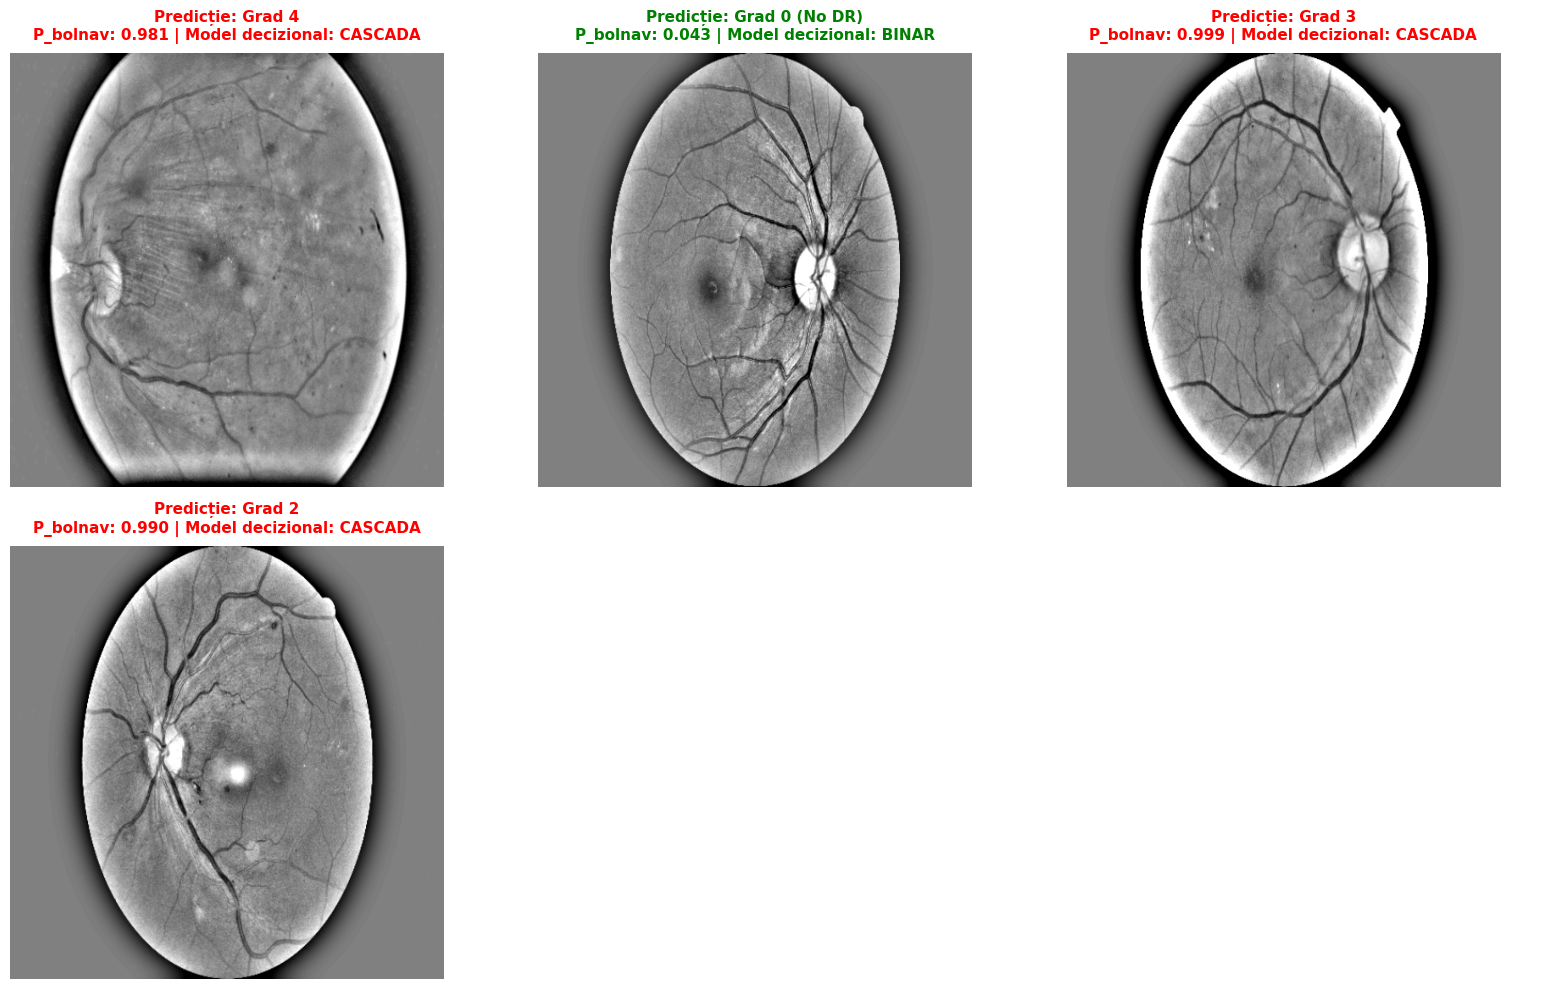

In [66]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# ... (păstrează funcțiile de încărcare model și prezice_imagine exact cum le aveai) ...

print("=== 🚀 DEMO INFERENȚĂ ÎN CASCADĂ (Binar -> Multi-Clasă) ===")

# Definim rutele clare pentru a forța extragerea din toate clasele
# (Ajustează numele folderului "0_sanatos" dacă l-ai numit altfel)
DIR_TEST_SANATOS = r'B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\eyepacs\eyepacs_binar\test\0_sanatos'
DIR_TEST_MULTI = r'B:\Projects\Disertatie\Diabetic-Retinopathy-Classifier\datasets\processed_by_me\eyepacs\eyepacs_1_4\test'

fisiere_demo = []

# 1. Extragem 2 imagini cu ochi Sănătoși (Grad 0) din testul binar
if os.path.exists(DIR_TEST_SANATOS):
    poze_0 = [os.path.join(DIR_TEST_SANATOS, f) for f in os.listdir(DIR_TEST_SANATOS) if f.endswith(('.png', '.jpg', '.jpeg'))]
    if poze_0:
        fisiere_demo.extend(random.sample(poze_0, min(2, len(poze_0))))

# 2. Extragem câte o imagine din fiecare stadiu (1, 2, 3, 4) din testul multi-clasă
stadii = ['stadiul_1', 'stadiul_2', 'stadiul_3', 'stadiul_4']
for stadiu in stadii:
    dir_stadiu = os.path.join(DIR_TEST_MULTI, stadiu)
    if os.path.exists(dir_stadiu):
        poze_stadiu = [os.path.join(dir_stadiu, f) for f in os.listdir(dir_stadiu) if f.endswith(('.png', '.jpg', '.jpeg'))]
        if poze_stadiu:
            fisiere_demo.append(random.choice(poze_stadiu))

# Amestecăm lista pentru un aspect dinamic în grilă
random.shuffle(fisiere_demo)

# Limităm la fix 6 imagini pentru un plot curat (2 rânduri x 3 coloane)
fisiere_demo = fisiere_demo[:6]

# ==========================================
# AFIȘAREA GRAFICĂ
# ==========================================
if not fisiere_demo:
    print("❌ Nu am găsit imagini. Verifică rutele folderelor de test.")
else:
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    axes = axes.flatten()

    for idx, img_path in enumerate(fisiere_demo):
        # 1. Rulăm inferența în cascadă
        rezultat = prezice_imagine(img_path)
        
        # 2. Încărcăm imaginea pentru display
        img_display = Image.open(img_path)
        
        # 3. Desenăm pe sub-grafic
        ax = axes[idx]
        ax.imshow(img_display)
        ax.axis('off') # Ascundem axele cu numere
        
        # 4. Construim textul rezultatului
        titlu = f"Predicție: {rezultat['eticheta']}\n"
        titlu += f"P_bolnav: {rezultat['p_sick']:.3f} | Model decizional: {rezultat['etapa'].upper()}"
        
        # Colorăm textul pentru impact vizual
        culoare = 'green' if rezultat['grad_final'] == 0 else 'red'
        
        ax.set_title(titlu, color=culoare, fontsize=11, fontweight='bold', pad=10)

    # Dacă avem mai puțin de 6 imagini găsite, ascundem pătratele goale
    for i in range(len(fisiere_demo), len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()